# Comprehensive Evaluation Metrics for Machine Learning

This notebook is a complete reference covering all major evaluation metrics across different ML domains:
- **Classification**: accuracy, precision, recall, F1, ROC/AUC, calibration, MCC, kappa
- **Regression**: MSE, RMSE, MAE, MAPE, sMAPE, RMSLE, R², Huber, quantile loss
- **Ranking**: NDCG, MAP, MRR, Precision@k, Recall@k, Hit Rate@k
- **Clustering**: Silhouette, Davies-Bouldin, Calinski-Harabasz, ARI, NMI, Fowlkes-Mallows
- **NLP**: BLEU, ROUGE, METEOR, ChrF, BERTScore, Perplexity
- **Computer Vision**: IoU, mAP, Dice, FID, PSNR, SSIM
- **Time Series**: MAE, RMSE, MAPE, sMAPE, MASE, RMSSE, CRPS
- **RAG/LLM**: RAGAS, G-Eval, QAGs, TruLens, DeepEval
- **Statistical Testing**: t-test, Wilcoxon, bootstrap CI, Friedman test


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import make_classification, make_regression, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score, average_precision_score,
    precision_recall_curve, log_loss, cohen_kappa_score,
    matthews_corrcoef, brier_score_loss, confusion_matrix,
    classification_report, balanced_accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score,
    explained_variance_score, max_error,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.cluster import KMeans
from scipy import stats
from scipy.stats import wilcoxon, friedmanchisquare
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("All libraries imported successfully!")

All libraries imported successfully!


## 1. Classification Metrics

### 1.1 Confusion Matrix Foundation

All classification metrics derive from the confusion matrix:

| | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | TP (True Positive) | FN (False Negative) |
| **Actual Negative** | FP (False Positive) | TN (True Negative) |

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall (Sensitivity)} = \frac{TP}{TP + FN}$$

$$\text{F1-Score} = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2TP}{2TP + FP + FN}$$

$$\text{Specificity} = \frac{TN}{TN + FP}$$

$$\text{Balanced Accuracy} = \frac{\text{Sensitivity} + \text{Specificity}}{2}$$

$$\text{G-Mean} = \sqrt{\text{Sensitivity} \times \text{Specificity}}$$

### Averaging Strategies
- **Macro**: unweighted mean across classes treats all classes equally
- **Micro**: compute globally by counting total TP, FP, FN dominated by frequent classes
- **Weighted**: weighted by class support accounts for class imbalance
- **Samples**: per-sample averaging used in multi-label classification


In [2]:
# Generate binary classification dataset
np.random.seed(42)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15,
                            n_redundant=5, random_state=42, weights=[0.7, 0.3])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTP={TP}, TN={TN}, FP={FP}, FN={FN}")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
specificity = TN / (TN + FP)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
g_mean = np.sqrt(recall * specificity)

print(f"\n{'Metric':<25} {'Value':<10}")
print("-" * 35)
print(f"{'Accuracy':<25} {accuracy:.4f}")
print(f"{'Precision':<25} {precision:.4f}")
print(f"{'Recall (Sensitivity)':<25} {recall:.4f}")
print(f"{'F1-Score':<25} {f1:.4f}")
print(f"{'Specificity':<25} {specificity:.4f}")
print(f"{'Balanced Accuracy':<25} {balanced_acc:.4f}")
print(f"{'G-Mean':<25} {g_mean:.4f}")

def accuracy_scratch(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

def precision_scratch(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    return TP / (TP + FP + 1e-10)

def recall_scratch(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP / (TP + FN + 1e-10)

def f1_scratch(y_true, y_pred):
    p = precision_scratch(y_true, y_pred)
    r = recall_scratch(y_true, y_pred)
    return 2 * p * r / (p + r + 1e-10)

print(f"\nScratch implementations:")
print(f"Accuracy (scratch):  {accuracy_scratch(y_test, y_pred):.4f}")
print(f"Precision (scratch): {precision_scratch(y_test, y_pred):.4f}")
print(f"Recall (scratch):    {recall_scratch(y_test, y_pred):.4f}")
print(f"F1-Score (scratch):  {f1_scratch(y_test, y_pred):.4f}")

Confusion Matrix:
[[132   7]
 [ 21  40]]

TP=40, TN=132, FP=7, FN=21

Metric                    Value     
-----------------------------------
Accuracy                  0.8600
Precision                 0.8511
Recall (Sensitivity)      0.6557
F1-Score                  0.7407
Specificity               0.9496
Balanced Accuracy         0.8027
G-Mean                    0.7891

Scratch implementations:
Accuracy (scratch):  0.8600
Precision (scratch): 0.8511
Recall (scratch):    0.6557
F1-Score (scratch):  0.7407


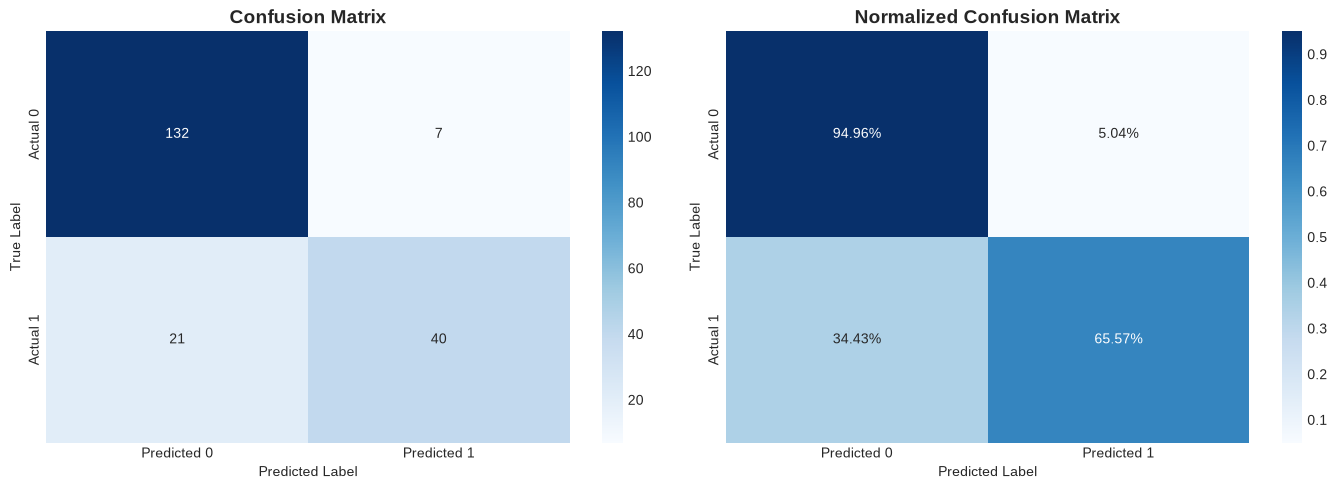


Classification Report:
              precision    recall  f1-score   support

     Class 0       0.86      0.95      0.90       139
     Class 1       0.85      0.66      0.74        61

    accuracy                           0.86       200
   macro avg       0.86      0.80      0.82       200
weighted avg       0.86      0.86      0.85       200



In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[1].set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

### 1.2 ROC Curve and AUC-ROC

The ROC curve plots True Positive Rate (TPR) vs False Positive Rate (FPR) at all classification thresholds:

$$TPR = \frac{TP}{TP + FN} \quad (\text{Recall/Sensitivity})$$

$$FPR = \frac{FP}{FP + TN} \quad (1 - \text{Specificity})$$

**AUC-ROC interpretation:**
- 0.5 = random classifier (diagonal line)
- 1.0 = perfect classifier
- < 0.5 = worse than random (model is inverting predictions)

AUC-ROC is equivalent to the probability that a randomly chosen positive example ranks higher than a randomly chosen negative example.

### 1.3 Precision-Recall Curve and AUC-PR

For **imbalanced datasets**, AUC-PR is more informative than AUC-ROC because it focuses on the minority (positive) class.

$$\text{Average Precision} = \sum_n (R_n - R_{n-1}) P_n$$

The baseline for a random classifier equals the class prevalence $\pi = P(y=1)$, unlike ROC where the baseline is always 0.5.


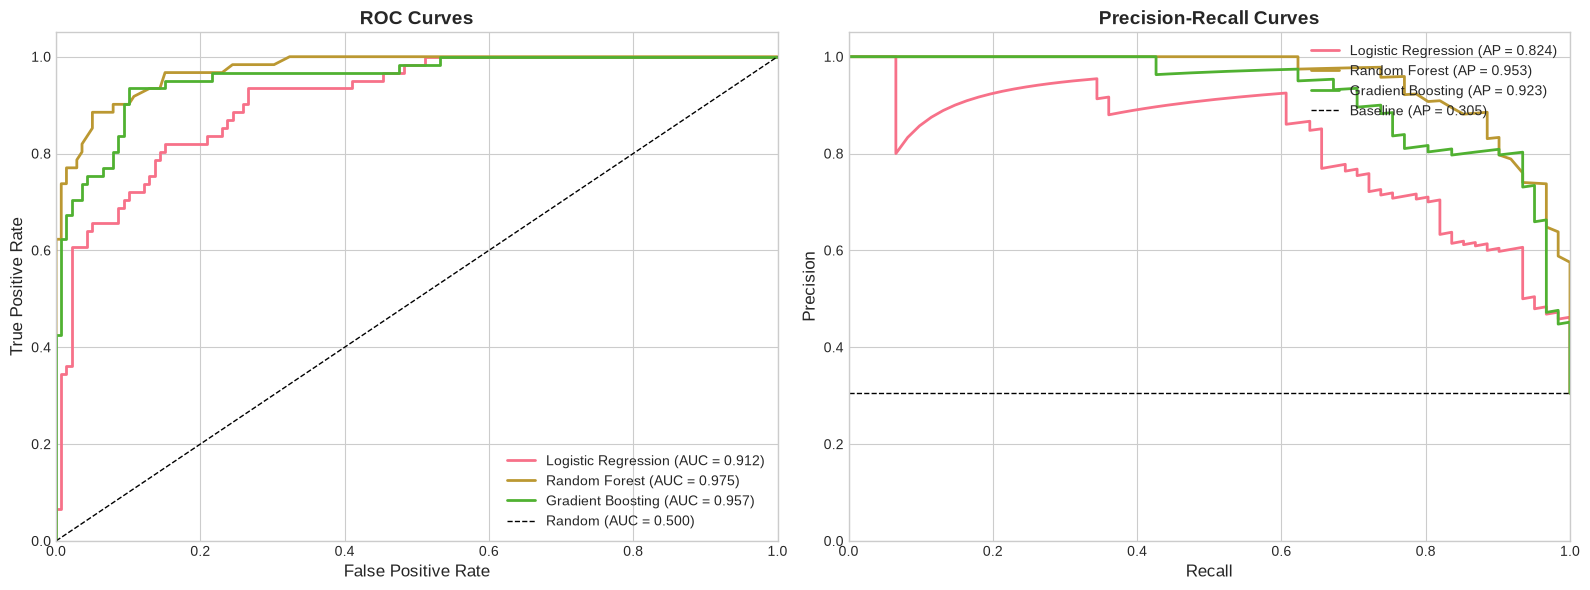

In [4]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob_m = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob_m)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

    precision_arr, recall_arr, _ = precision_recall_curve(y_test, y_prob_m)
    ap = average_precision_score(y_test, y_prob_m)
    axes[1].plot(recall_arr, precision_arr, lw=2, label=f'{name} (AP = {ap:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')

baseline = np.sum(y_test) / len(y_test)
axes[1].axhline(y=baseline, color='k', linestyle='--', lw=1, label=f'Baseline (AP = {baseline:.3f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

### 1.4 Log Loss (Binary Cross-Entropy)

$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log(p_i) + (1-y_i)\log(1-p_i)\right]$$

- Lower is better; 0 = perfect
- Penalizes confident wrong predictions heavily
- Measures probability calibration quality
- A random classifier on balanced data has log loss ≈ 0.693 (= ln 2)

### 1.5 Cohen's Kappa

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

where $p_o$ = observed agreement (accuracy), $p_e$ = expected agreement by chance.

**Kappa interpretation scale:**
- $< 0$: Less than chance agreement
- $0.0 - 0.2$: Slight
- $0.2 - 0.4$: Fair
- $0.4 - 0.6$: Moderate
- $0.6 - 0.8$: Substantial
- $0.8 - 1.0$: Almost perfect

### 1.6 Matthews Correlation Coefficient (MCC)

$$\text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

- Range: $[-1, +1]$ where $+1$ = perfect, $0$ = random, $-1$ = perfect inverse
- Considered the **best single metric for imbalanced datasets** accounts for all four quadrants
- Equivalent to the Pearson correlation between true and predicted binary labels


In [5]:
ll = log_loss(y_test, y_prob)
print(f"Log Loss: {ll:.4f}")

def log_loss_scratch(y_true, y_prob, eps=1e-15):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

print(f"Log Loss (scratch): {log_loss_scratch(y_test, y_prob):.4f}")

kappa = cohen_kappa_score(y_test, y_pred)
print(f"\nCohen's Kappa: {kappa:.4f}")

def cohens_kappa_scratch(y_true, y_pred):
    n = len(y_true)
    cm_k = confusion_matrix(y_true, y_pred)
    po = np.trace(cm_k) / n
    row_sums = cm_k.sum(axis=1) / n
    col_sums = cm_k.sum(axis=0) / n
    pe = np.sum(row_sums * col_sums)
    return (po - pe) / (1 - pe)

print(f"Cohen's Kappa (scratch): {cohens_kappa_scratch(y_test, y_pred):.4f}")

mcc = matthews_corrcoef(y_test, y_pred)
print(f"\nMCC: {mcc:.4f}")

def mcc_scratch(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    denom = np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    return (TP*TN - FP*FN) / (denom + 1e-10)

print(f"MCC (scratch): {mcc_scratch(y_test, y_pred):.4f}")

def kappa_interpret(k):
    if k < 0: return "Less than chance"
    elif k < 0.2: return "Slight"
    elif k < 0.4: return "Fair"
    elif k < 0.6: return "Moderate"
    elif k < 0.8: return "Substantial"
    else: return "Almost perfect"

print(f"\nKappa interpretation: {kappa_interpret(kappa)}")

Log Loss: 0.3436
Log Loss (scratch): 0.3436

Cohen's Kappa: 0.6470
Cohen's Kappa (scratch): 0.6470

MCC: 0.6574
MCC (scratch): 0.6574

Kappa interpretation: Substantial


### 1.7 Calibration Metrics

A **well-calibrated** model's predicted probability $p$ means: among all predictions with confidence $p$, approximately fraction $p$ are actually positive.

**Brier Score** mean squared error of probability predictions:
$$\text{Brier Score} = \frac{1}{n}\sum_{i=1}^{n}(p_i - y_i)^2$$
Range: [0, 1], lower is better. Can be decomposed into refinement + calibration.

**Expected Calibration Error (ECE)** partition predictions into $M$ equally-spaced bins:
$$\text{ECE} = \sum_{m=1}^{M}\frac{|B_m|}{n}\left|\text{acc}(B_m) - \text{conf}(B_m)\right|$$

**Maximum Calibration Error (MCE)** worst-case bin calibration error:
$$\text{MCE} = \max_{m \in \{1,\ldots,M\}} \left|\text{acc}(B_m) - \text{conf}(B_m)\right|$$

**Calibration methods:** Platt scaling (logistic), isotonic regression, temperature scaling.


Brier Score: 0.1071
Brier Score (scratch): 0.1071
ECE: 0.0324
MCE: 0.2480


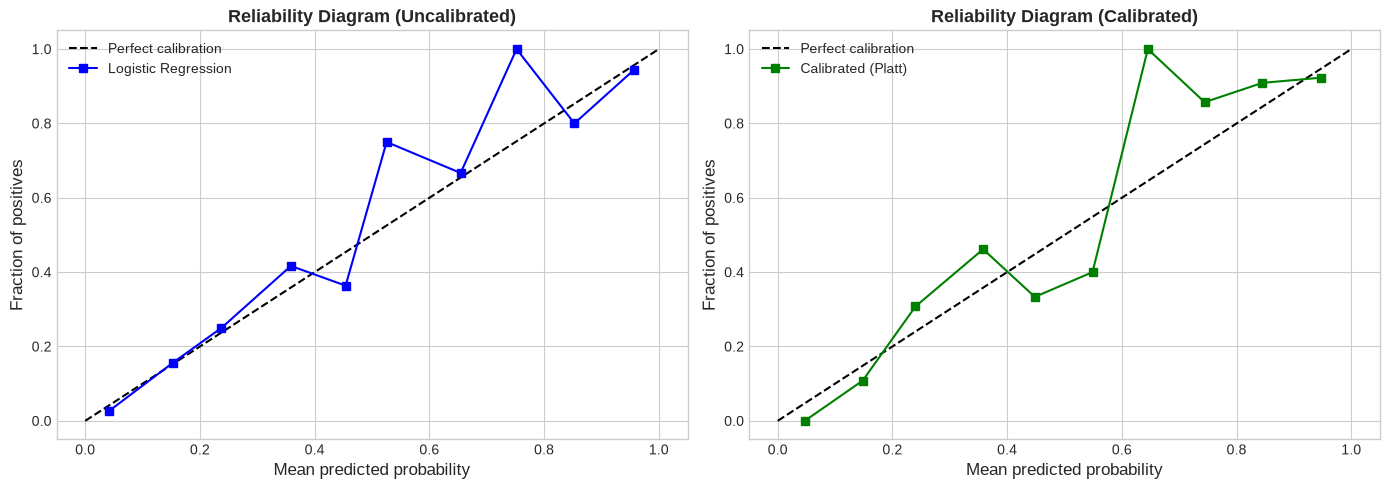


Brier Score (calibrated): 0.1083 vs (uncalibrated): 0.1071


In [6]:
brier = brier_score_loss(y_test, y_prob)
print(f"Brier Score: {brier:.4f}")

def brier_scratch(y_true, y_prob):
    return np.mean((y_prob - y_true) ** 2)

print(f"Brier Score (scratch): {brier_scratch(y_test, y_prob):.4f}")

def compute_ece_mce(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    mce = 0.0
    n = len(y_true)
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        bin_ece = (mask.sum() / n) * abs(acc - conf)
        ece += bin_ece
        mce = max(mce, abs(acc - conf))
    return ece, mce

ece, mce = compute_ece_mce(y_test, y_prob)
print(f"ECE: {ece:.4f}")
print(f"MCE: {mce:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[0].plot(mean_pred, fraction_pos, 's-', label='Logistic Regression', color='blue')
axes[0].set_xlabel('Mean predicted probability', fontsize=12)
axes[0].set_ylabel('Fraction of positives', fontsize=12)
axes[0].set_title('Reliability Diagram (Uncalibrated)', fontsize=13, fontweight='bold')
axes[0].legend()

calibrated_clf = CalibratedClassifierCV(
    LogisticRegression(random_state=42, max_iter=1000), cv=5, method='sigmoid')
calibrated_clf.fit(X_train, y_train)
y_prob_cal = calibrated_clf.predict_proba(X_test)[:, 1]

fraction_pos_cal, mean_pred_cal = calibration_curve(y_test, y_prob_cal, n_bins=10)
axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[1].plot(mean_pred_cal, fraction_pos_cal, 's-', label='Calibrated (Platt)', color='green')
axes[1].set_xlabel('Mean predicted probability', fontsize=12)
axes[1].set_ylabel('Fraction of positives', fontsize=12)
axes[1].set_title('Reliability Diagram (Calibrated)', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

brier_cal = brier_score_loss(y_test, y_prob_cal)
print(f"\nBrier Score (calibrated): {brier_cal:.4f} vs (uncalibrated): {brier:.4f}")

### 1.8 Multi-class Classification

**Strategies for extending binary classifiers:**
- **One-vs-Rest (OvR)**: train $K$ binary classifiers, one per class against all others
- **One-vs-One (OvO)**: train $K(K-1)/2$ classifiers for each pair of classes

**Multi-class ROC:** compute ROC curve for each class using OvR, then average (macro) or weight by support (weighted).

**Multi-class confusion matrix:** $K \times K$ matrix where entry $(i,j)$ is the number of samples with true class $i$ predicted as class $j$.


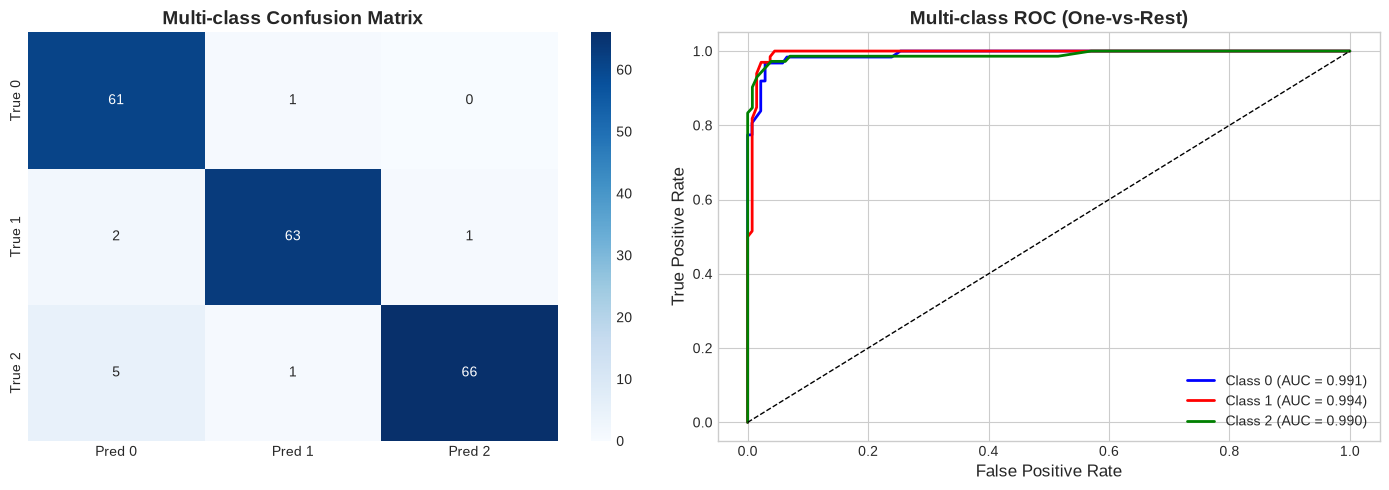

Averaging strategies for F1-Score:
  Macro    (unweighted mean): 0.9500
  Micro    (global TP/FP/FN): 0.9500
  Weighted (support-weighted): 0.9502

              precision    recall  f1-score   support

           0       0.90      0.98      0.94        62
           1       0.97      0.95      0.96        66
           2       0.99      0.92      0.95        72

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



In [7]:
X_mc, y_mc = make_classification(n_samples=1000, n_features=20, n_informative=10,
                                   n_classes=3, n_clusters_per_class=1, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_mc, y_mc, test_size=0.2, random_state=42)

clf_mc = RandomForestClassifier(n_estimators=100, random_state=42)
clf_mc.fit(X_tr, y_tr)
y_pred_mc = clf_mc.predict(X_te)
y_prob_mc = clf_mc.predict_proba(X_te)

cm_mc = confusion_matrix(y_te, y_pred_mc)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_mc, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'Pred {i}' for i in range(3)],
            yticklabels=[f'True {i}' for i in range(3)])
axes[0].set_title('Multi-class Confusion Matrix', fontsize=14, fontweight='bold')

classes = [0, 1, 2]
colors = ['blue', 'red', 'green']
for cls, color in zip(classes, colors):
    y_bin = (y_te == cls).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, y_prob_mc[:, cls])
    roc_auc_mc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'Class {cls} (AUC = {roc_auc_mc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('Multi-class ROC (One-vs-Rest)', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print("Averaging strategies for F1-Score:")
print(f"  Macro    (unweighted mean): {f1_score(y_te, y_pred_mc, average='macro'):.4f}")
print(f"  Micro    (global TP/FP/FN): {f1_score(y_te, y_pred_mc, average='micro'):.4f}")
print(f"  Weighted (support-weighted): {f1_score(y_te, y_pred_mc, average='weighted'):.4f}")
print(f"\n{classification_report(y_te, y_pred_mc)}")

## 2. Regression Metrics

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

$$\text{RMSE} = \sqrt{\text{MSE}}$$

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

$$\text{MAPE} = \frac{1}{n}\sum_{i=1}^{n}\frac{|y_i - \hat{y}_i|}{|y_i|} \times 100\%$$

$$\text{sMAPE} = \frac{2}{n}\sum_{i=1}^{n}\frac{|y_i - \hat{y}_i|}{|y_i| + |\hat{y}_i|} \times 100\%$$

$$\text{RMSLE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\log(1+\hat{y}_i) - \log(1+y_i))^2}$$

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$$

$$\text{Adjusted } R^2 = 1 - (1-R^2)\frac{n-1}{n-p-1}$$

**Huber Loss** (robust to outliers, $\delta$ controls transition):
$$L_\delta(y, \hat{y}) = \begin{cases}\frac{1}{2}(y-\hat{y})^2 & \text{if } |y-\hat{y}| \leq \delta \\ \delta(|y-\hat{y}| - \frac{\delta}{2}) & \text{otherwise}\end{cases}$$

**Quantile (Pinball) Loss** (for quantile regression at quantile $q$):
$$L_q(y, \hat{y}) = \begin{cases}q(y-\hat{y}) & \text{if } y \geq \hat{y} \\ (1-q)(\hat{y}-y) & \text{otherwise}\end{cases}$$

At $q=0.5$, quantile loss = MAE/2.


In [8]:
X_reg, y_reg = make_regression(n_samples=1000, n_features=10, noise=20, random_state=42)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X_tr_r, y_tr_r)
y_pred_r = reg.predict(X_te_r)
n, p = X_te_r.shape

def mse_scratch(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse_scratch(y_true, y_pred):
    return np.sqrt(mse_scratch(y_true, y_pred))

def mae_scratch(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mape_scratch(y_true, y_pred, eps=1e-10):
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

def smape_scratch(y_true, y_pred, eps=1e-10):
    return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100

def rmsle_scratch(y_true, y_pred):
    y_pred_pos = np.maximum(y_pred, 0)
    y_true_pos = np.maximum(y_true, 0)
    return np.sqrt(np.mean((np.log1p(y_pred_pos) - np.log1p(y_true_pos)) ** 2))

def r2_scratch(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

def adjusted_r2_scratch(y_true, y_pred, n_features):
    r2 = r2_scratch(y_true, y_pred)
    n = len(y_true)
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

def huber_loss(y_true, y_pred, delta=1.0):
    diff = np.abs(y_true - y_pred)
    return np.mean(np.where(diff <= delta, 0.5 * diff**2, delta * (diff - 0.5 * delta)))

def quantile_loss(y_true, y_pred, q=0.5):
    diff = y_true - y_pred
    return np.mean(np.where(diff >= 0, q * diff, (q - 1) * diff))

mse = mean_squared_error(y_te_r, y_pred_r)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_te_r, y_pred_r)
r2 = r2_score(y_te_r, y_pred_r)
evs = explained_variance_score(y_te_r, y_pred_r)
me = max_error(y_te_r, y_pred_r)

print(f"{'Metric':<30} {'Scratch':<15} {'Sklearn':<15}")
print("-" * 60)
print(f"{'MSE':<30} {mse_scratch(y_te_r, y_pred_r):<15.4f} {mse:<15.4f}")
print(f"{'RMSE':<30} {rmse_scratch(y_te_r, y_pred_r):<15.4f} {rmse:<15.4f}")
print(f"{'MAE':<30} {mae_scratch(y_te_r, y_pred_r):<15.4f} {mae:<15.4f}")
print(f"{'MAPE (%)':<30} {mape_scratch(y_te_r, y_pred_r):<15.4f} N/A")
print(f"{'sMAPE (%)':<30} {smape_scratch(y_te_r, y_pred_r):<15.4f} N/A")
print(f"{'R\u00b2':<30} {r2_scratch(y_te_r, y_pred_r):<15.4f} {r2:<15.4f}")
print(f"{'Adjusted R\u00b2':<30} {adjusted_r2_scratch(y_te_r, y_pred_r, p):<15.4f} N/A")
print(f"{'Huber Loss (\u03b4=1)':<30} {huber_loss(y_te_r, y_pred_r):<15.4f} N/A")
print(f"{'Quantile Loss (q=0.5)':<30} {quantile_loss(y_te_r, y_pred_r):<15.4f} N/A")
print(f"{'Explained Variance Score':<30} N/A            {evs:<15.4f}")
print(f"{'Max Error':<30} N/A            {me:<15.4f}")

Metric                         Scratch         Sklearn        
------------------------------------------------------------
MSE                            380.4766        380.4766       
RMSE                           19.5058         19.5058        
MAE                            15.5467         15.5467        
MAPE (%)                       40.7530         N/A
sMAPE (%)                      34.3771         N/A
R²                             0.9774          0.9774         
Adjusted R²                    0.9762          N/A
Huber Loss (δ=1)               15.0563         N/A
Quantile Loss (q=0.5)          7.7733          N/A
Explained Variance Score       N/A            0.9775         
Max Error                      N/A            59.7509        


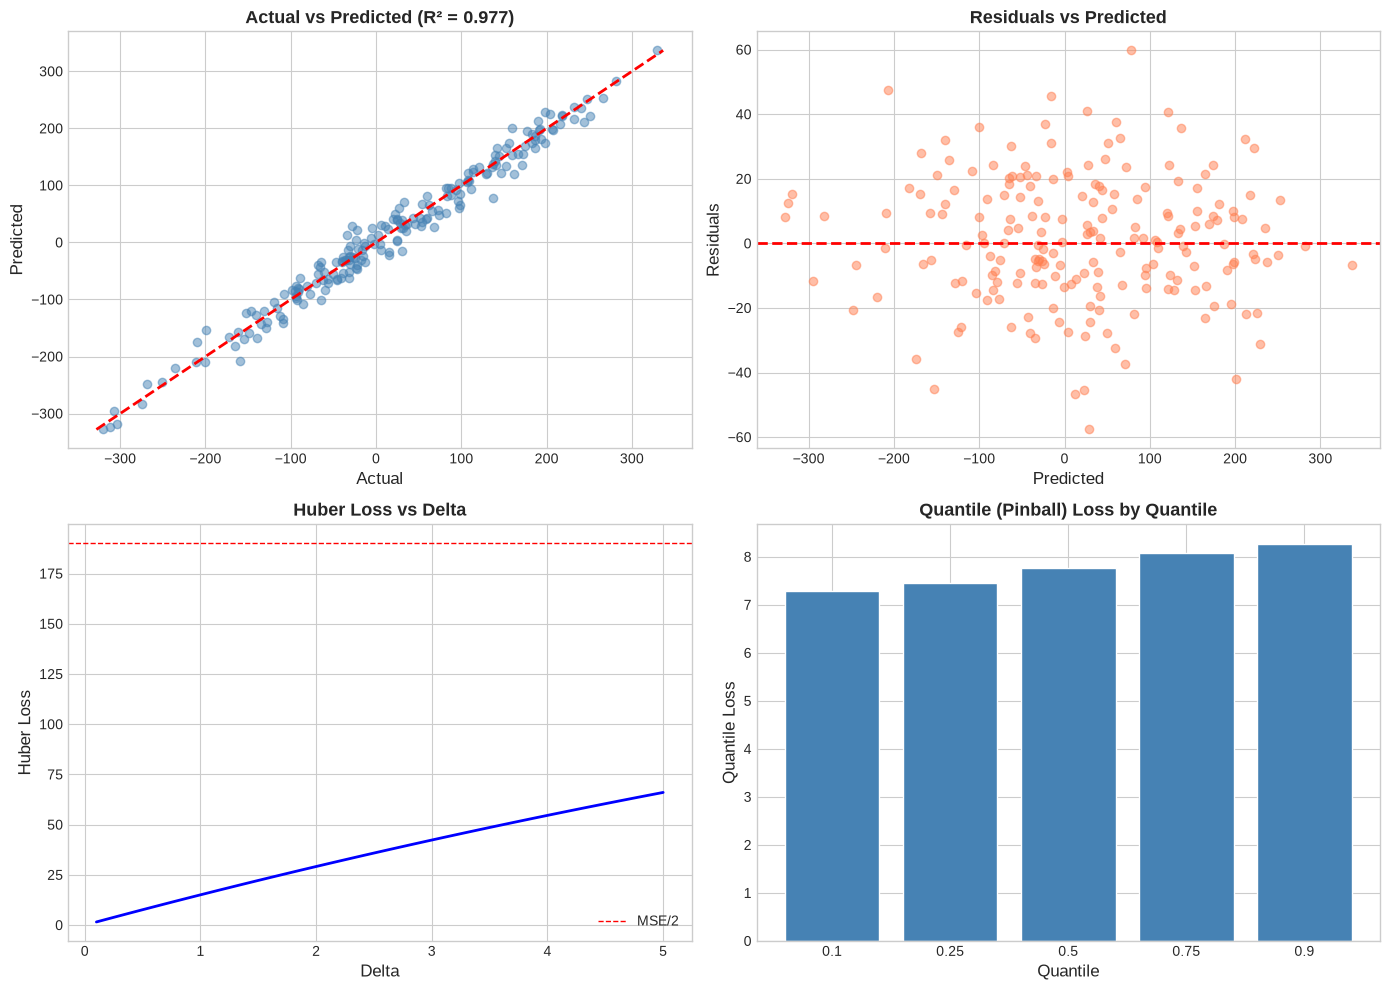

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(y_te_r, y_pred_r, alpha=0.5, color='steelblue')
lims = [min(y_te_r.min(), y_pred_r.min()), max(y_te_r.max(), y_pred_r.max())]
axes[0,0].plot(lims, lims, 'r--', lw=2)
axes[0,0].set_xlabel('Actual', fontsize=12)
axes[0,0].set_ylabel('Predicted', fontsize=12)
axes[0,0].set_title(f'Actual vs Predicted (R\u00b2 = {r2:.3f})', fontsize=13, fontweight='bold')

residuals = y_te_r - y_pred_r
axes[0,1].scatter(y_pred_r, residuals, alpha=0.5, color='coral')
axes[0,1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0,1].set_xlabel('Predicted', fontsize=12)
axes[0,1].set_ylabel('Residuals', fontsize=12)
axes[0,1].set_title('Residuals vs Predicted', fontsize=13, fontweight='bold')

delta_vals = np.linspace(0.1, 5, 100)
huber_vals = [huber_loss(y_te_r, y_pred_r, d) for d in delta_vals]
axes[1,0].plot(delta_vals, huber_vals, 'b-', lw=2)
axes[1,0].axhline(y=0.5*mse, color='r', linestyle='--', lw=1, label='MSE/2')
axes[1,0].set_xlabel('Delta', fontsize=12)
axes[1,0].set_ylabel('Huber Loss', fontsize=12)
axes[1,0].set_title('Huber Loss vs Delta', fontsize=13, fontweight='bold')
axes[1,0].legend()

q_vals = [0.1, 0.25, 0.5, 0.75, 0.9]
q_losses = [quantile_loss(y_te_r, y_pred_r, q) for q in q_vals]
axes[1,1].bar([str(q) for q in q_vals], q_losses, color='steelblue', edgecolor='white')
axes[1,1].set_xlabel('Quantile', fontsize=12)
axes[1,1].set_ylabel('Quantile Loss', fontsize=12)
axes[1,1].set_title('Quantile (Pinball) Loss by Quantile', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Ranking Metrics

Ranking metrics evaluate the quality of ordered lists, used in information retrieval, recommendation systems, and search engines.

### Discounted Cumulative Gain (NDCG)

$$\text{DCG}_p = \sum_{i=1}^{p}\frac{2^{rel_i} - 1}{\log_2(i+1)}$$

$$\text{NDCG}_p = \frac{\text{DCG}_p}{\text{IDCG}_p}$$

where IDCG is the ideal (best possible) DCG.

### Mean Average Precision (MAP)

$$\text{MAP} = \frac{1}{|Q|}\sum_{q=1}^{|Q|}\text{AP}(q), \quad \text{AP} = \frac{\sum_{k=1}^{n}P(k)\cdot rel(k)}{\text{# relevant docs}}$$

### Mean Reciprocal Rank (MRR)

$$\text{MRR} = \frac{1}{|Q|}\sum_{i=1}^{|Q|}\frac{1}{\text{rank}_i}$$

where $\text{rank}_i$ is the rank of the first relevant document for query $i$.

### Precision@k, Recall@k, Hit Rate@k

- **Precision@k**: fraction of top-$k$ retrieved items that are relevant
- **Recall@k**: fraction of all relevant items that appear in the top-$k$
- **Hit Rate@k**: fraction of queries that have at least one relevant item in the top-$k$


In [10]:
def dcg_at_k(relevances, k):
    relevances = np.array(relevances[:k], dtype=float)
    if len(relevances) == 0:
        return 0.0
    discounts = np.log2(np.arange(2, len(relevances) + 2))
    return np.sum((2**relevances - 1) / discounts)

def ndcg_at_k(relevances, k):
    dcg = dcg_at_k(relevances, k)
    ideal = sorted(relevances, reverse=True)
    idcg = dcg_at_k(ideal, k)
    return dcg / idcg if idcg > 0 else 0.0

def average_precision(relevances):
    hits = 0
    sum_prec = 0.0
    for i, rel in enumerate(relevances):
        if rel > 0:
            hits += 1
            sum_prec += hits / (i + 1)
    n_relevant = sum(1 for r in relevances if r > 0)
    return sum_prec / n_relevant if n_relevant > 0 else 0.0

def precision_at_k(relevances, k):
    return sum(1 for r in relevances[:k] if r > 0) / k

def recall_at_k(relevances, k, total_relevant):
    return sum(1 for r in relevances[:k] if r > 0) / total_relevant if total_relevant > 0 else 0.0

def hit_rate_at_k(queries_relevances, k):
    hits = sum(1 for rels in queries_relevances if any(r > 0 for r in rels[:k]))
    return hits / len(queries_relevances)

def mrr(queries_relevances):
    rr_sum = 0.0
    for rels in queries_relevances:
        for i, r in enumerate(rels):
            if r > 0:
                rr_sum += 1.0 / (i + 1)
                break
    return rr_sum / len(queries_relevances)

np.random.seed(42)
n_queries = 5
n_items = 10
queries_relevances = [
    np.random.choice([0, 0, 0, 1, 2, 3], size=n_items).tolist()
    for _ in range(n_queries)
]

k = 5
print(f"{'Query':<8} {'NDCG@5':<10} {'AP':<10} {'P@5':<10} {'R@5':<10}")
print("-" * 48)
total_rel_per_query = [sum(1 for r in q if r > 0) for q in queries_relevances]

for i, (rels, tot_rel) in enumerate(zip(queries_relevances, total_rel_per_query)):
    print(f"{'Q'+str(i+1):<8} "
          f"{ndcg_at_k(rels, k):<10.4f} "
          f"{average_precision(rels):<10.4f} "
          f"{precision_at_k(rels, k):<10.4f} "
          f"{recall_at_k(rels, k, tot_rel):<10.4f}")

mean_ndcg = np.mean([ndcg_at_k(r, k) for r in queries_relevances])
map_score = np.mean([average_precision(r) for r in queries_relevances])
mrr_score = mrr(queries_relevances)
hr = hit_rate_at_k(queries_relevances, k)

print(f"\nAggregate Metrics:")
print(f"  Mean NDCG@5:    {mean_ndcg:.4f}")
print(f"  MAP:            {map_score:.4f}")
print(f"  MRR:            {mrr_score:.4f}")
print(f"  Hit Rate@5:     {hr:.4f}")

Query    NDCG@5     AP         P@5        R@5       
------------------------------------------------
Q1       0.6622     0.8100     0.8000     0.8000    
Q2       0.3490     0.7497     0.6000     0.4286    
Q3       0.5538     0.7295     0.6000     0.6000    
Q4       0.2313     0.5973     0.6000     0.4286    
Q5       0.4569     0.3771     0.4000     0.5000    

Aggregate Metrics:
  Mean NDCG@5:    0.4506
  MAP:            0.6527
  MRR:            0.7333
  Hit Rate@5:     1.0000


## 4. Clustering Metrics

Internal validation (no ground truth needed):

**Silhouette Score**: measures how similar an object is to its own cluster vs other clusters.

$$\text{Silhouette}(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

where $a(i)$ = mean intra-cluster distance, $b(i)$ = mean distance to nearest other cluster. Range: $[-1, 1]$, higher is better.

**Davies-Bouldin Index**: average ratio of within-cluster scatter to between-cluster separation. Lower is better.

**Calinski-Harabasz Index**: ratio of between-cluster to within-cluster dispersion. Higher is better.

External validation (require ground truth labels):

**ARI**: adjusted for chance, range $[-1, 1]$.
$$\text{ARI} = \frac{\text{RI} - E[\text{RI}]}{\max(\text{RI}) - E[\text{RI}]}$$

**NMI**: normalized mutual information between true and predicted cluster labels, range $[0, 1]$.

**Fowlkes-Mallows**: geometric mean of pairwise precision and recall, range $[0, 1]$.

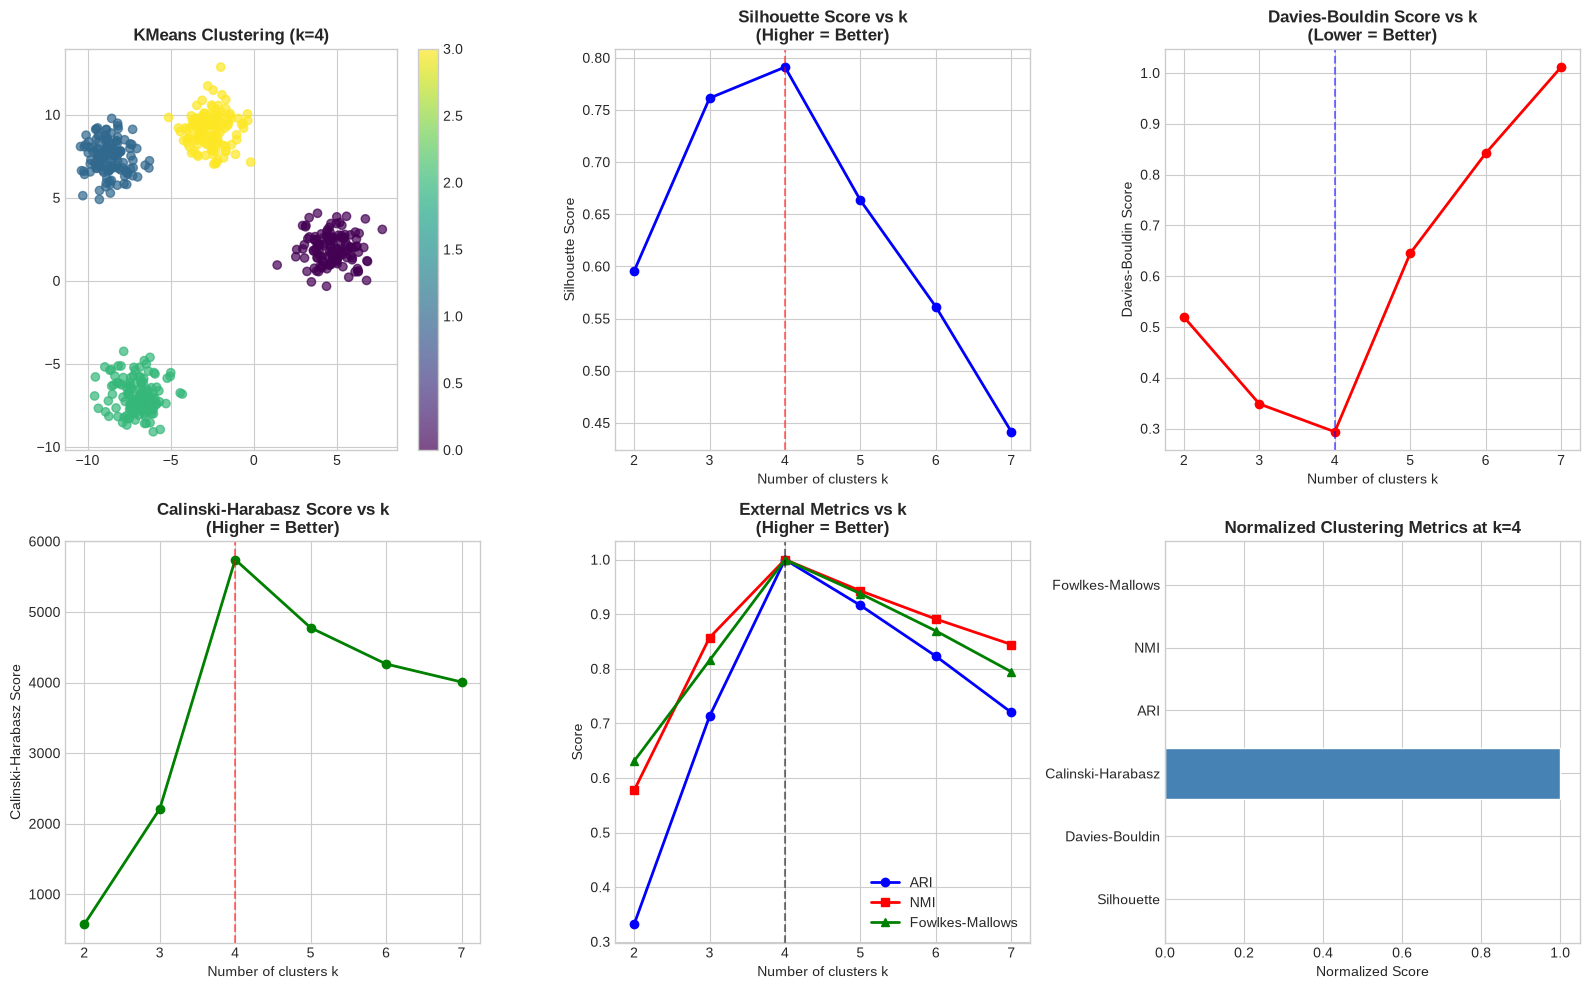


Clustering Metrics at k=4:
  Silhouette               : 0.7911
  Davies-Bouldin           : 0.2939
  Calinski-Harabasz        : 5742.0358
  ARI                      : 1.0000
  NMI                      : 1.0000
  Fowlkes-Mallows          : 1.0000


In [11]:
X_clust, y_clust_true = make_blobs(n_samples=500, n_features=2, centers=4,
                                    cluster_std=1.0, random_state=42)

k_range = range(2, 8)
silhouette_scores = []
db_scores = []
ch_scores = []
ari_scores = []
nmi_scores = []
fm_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clust)
    silhouette_scores.append(silhouette_score(X_clust, labels))
    db_scores.append(davies_bouldin_score(X_clust, labels))
    ch_scores.append(calinski_harabasz_score(X_clust, labels))
    ari_scores.append(adjusted_rand_score(y_clust_true, labels))
    nmi_scores.append(normalized_mutual_info_score(y_clust_true, labels))
    fm_scores.append(fowlkes_mallows_score(y_clust_true, labels))

kmeans_opt = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_opt = kmeans_opt.fit_predict(X_clust)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

scatter = axes[0,0].scatter(X_clust[:, 0], X_clust[:, 1], c=labels_opt, cmap='viridis', alpha=0.7)
axes[0,0].set_title('KMeans Clustering (k=4)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[0,0])

axes[0,1].plot(list(k_range), silhouette_scores, 'bo-', lw=2)
axes[0,1].set_xlabel('Number of clusters k')
axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].set_title('Silhouette Score vs k\n(Higher = Better)', fontsize=12, fontweight='bold')
axes[0,1].axvline(x=4, color='r', linestyle='--', alpha=0.5)

axes[0,2].plot(list(k_range), db_scores, 'ro-', lw=2)
axes[0,2].set_xlabel('Number of clusters k')
axes[0,2].set_ylabel('Davies-Bouldin Score')
axes[0,2].set_title('Davies-Bouldin Score vs k\n(Lower = Better)', fontsize=12, fontweight='bold')
axes[0,2].axvline(x=4, color='b', linestyle='--', alpha=0.5)

axes[1,0].plot(list(k_range), ch_scores, 'go-', lw=2)
axes[1,0].set_xlabel('Number of clusters k')
axes[1,0].set_ylabel('Calinski-Harabasz Score')
axes[1,0].set_title('Calinski-Harabasz Score vs k\n(Higher = Better)', fontsize=12, fontweight='bold')
axes[1,0].axvline(x=4, color='r', linestyle='--', alpha=0.5)

axes[1,1].plot(list(k_range), ari_scores, 'b-o', label='ARI', lw=2)
axes[1,1].plot(list(k_range), nmi_scores, 'r-s', label='NMI', lw=2)
axes[1,1].plot(list(k_range), fm_scores, 'g-^', label='Fowlkes-Mallows', lw=2)
axes[1,1].set_xlabel('Number of clusters k')
axes[1,1].set_ylabel('Score')
axes[1,1].set_title('External Metrics vs k\n(Higher = Better)', fontsize=12, fontweight='bold')
axes[1,1].legend()
axes[1,1].axvline(x=4, color='k', linestyle='--', alpha=0.5)

metrics_k4 = {
    'Silhouette': silhouette_score(X_clust, labels_opt),
    'Davies-Bouldin': davies_bouldin_score(X_clust, labels_opt),
    'Calinski-Harabasz': calinski_harabasz_score(X_clust, labels_opt),
    'ARI': adjusted_rand_score(y_clust_true, labels_opt),
    'NMI': normalized_mutual_info_score(y_clust_true, labels_opt),
    'Fowlkes-Mallows': fowlkes_mallows_score(y_clust_true, labels_opt)
}
max_abs = max(abs(v) for v in metrics_k4.values())
axes[1,2].barh(list(metrics_k4.keys()),
               [v/max_abs for v in metrics_k4.values()],
               color=['steelblue']*3 + ['coral']*3, edgecolor='white')
axes[1,2].set_title('Normalized Clustering Metrics at k=4', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('Normalized Score')

plt.tight_layout()
plt.show()
print("\nClustering Metrics at k=4:")
for m, v in metrics_k4.items():
    print(f"  {m:<25}: {v:.4f}")

## 5. NLP Metrics

### 5.1 BLEU Score

$$\text{BLEU} = \text{BP} \cdot \exp\left(\sum_{n=1}^{N} w_n \log p_n\right)$$

where $\text{BP} = \min(1, e^{1-r/c})$ is the brevity penalty ($c$ = hypothesis length, $r$ = reference length).

### 5.2 ROUGE

ROUGE-N: overlap of N-grams between hypothesis and reference.
$$\text{ROUGE-N} = \frac{\sum_{\text{gram}_n \in \text{Ref}} \text{Count}_{\text{match}}(\text{gram}_n)}{\sum_{\text{gram}_n \in \text{Ref}} \text{Count}(\text{gram}_n)}$$
ROUGE-L: based on Longest Common Subsequence (LCS).

### 5.3 BERTScore

Uses contextual embeddings from BERT to compute token-level similarity:
$$P_{\text{BERT}} = \frac{1}{|\hat{x}|} \sum_{\hat{x}_i \in \hat{x}} \max_{x_j \in x} \hat{x}_i^T x_j, \quad R_{\text{BERT}} = \frac{1}{|x|} \sum_{x_j \in x} \max_{\hat{x}_i \in \hat{x}} \hat{x}_i^T x_j$$

### 5.4 Perplexity

$$\text{PPL}(W) = \exp\left(-\frac{1}{N}\sum_{i=1}^{N}\log P(w_i | w_1, \ldots, w_{i-1})\right)$$

Lower is better. A random model over vocabulary $V$ has PPL $= V$.

### 5.5 Other Metrics
- **METEOR**: precision + recall with synonym matching and order penalty
- **ChrF**: character n-gram F-score robust to morphological variation
- **ChrF++**: ChrF with added word n-grams
- **COMET**: neural reference-based MT metric trained on human judgments
- **BLEURT**: BERT-based metric fine-tuned on human ratings

In [12]:
from collections import Counter
import math

def ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def bleu_score(reference, hypothesis, max_n=4):
    ref_tokens = reference.lower().split()
    hyp_tokens = hypothesis.lower().split()
    c = len(hyp_tokens)
    r = len(ref_tokens)
    bp = 1.0 if c >= r else math.exp(1 - r/c)
    precisions = []
    for n in range(1, max_n + 1):
        ref_ngrams = Counter(ngrams(ref_tokens, n))
        hyp_ngrams = Counter(ngrams(hyp_tokens, n))
        clipped = sum(min(count, ref_ngrams[gram]) for gram, count in hyp_ngrams.items())
        total = sum(hyp_ngrams.values())
        precisions.append(clipped / total if total > 0 else 0.0)
    log_avg = sum(math.log(max(p, 1e-10)) for p in precisions) / max_n
    return bp * math.exp(log_avg)

def rouge_n(reference, hypothesis, n):
    ref_tokens = reference.lower().split()
    hyp_tokens = hypothesis.lower().split()
    ref_ngrams = Counter(ngrams(ref_tokens, n))
    hyp_ngrams = Counter(ngrams(hyp_tokens, n))
    overlap = sum(min(count, hyp_ngrams[gram]) for gram, count in ref_ngrams.items())
    recall = overlap / max(sum(ref_ngrams.values()), 1)
    precision = overlap / max(sum(hyp_ngrams.values()), 1)
    f1 = 2 * precision * recall / (precision + recall + 1e-10)
    return {'recall': recall, 'precision': precision, 'f1': f1}

def lcs_length(x, y):
    m, n = len(x), len(y)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(1, m+1):
        for j in range(1, n+1):
            if x[i-1] == y[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[m][n]

def rouge_l(reference, hypothesis):
    ref_tokens = reference.lower().split()
    hyp_tokens = hypothesis.lower().split()
    lcs = lcs_length(ref_tokens, hyp_tokens)
    recall = lcs / max(len(ref_tokens), 1)
    precision = lcs / max(len(hyp_tokens), 1)
    f1 = 2 * precision * recall / (precision + recall + 1e-10)
    return {'recall': recall, 'precision': precision, 'f1': f1}

reference = "The cat is on the mat near the window"
hypothesis1 = "The cat is on the mat"
hypothesis2 = "A feline rests upon a rug"
hypothesis3 = "The cat sits on the mat near the glass"
hypotheses = [hypothesis1, hypothesis2, hypothesis3]

print("NLP Metric Comparison:")
print("="*70)
print(f"Reference:    {reference}")
print(f"Hypothesis 1: {hypothesis1}")
print(f"Hypothesis 2: {hypothesis2}")
print(f"Hypothesis 3: {hypothesis3}")
print()

for i, hyp in enumerate(hypotheses, 1):
    bleu = bleu_score(reference, hyp)
    r1 = rouge_n(reference, hyp, 1)
    rg2 = rouge_n(reference, hyp, 2)
    rl = rouge_l(reference, hyp)
    print(f"Hypothesis {i}:")
    print(f"  BLEU:       {bleu:.4f}")
    print(f"  ROUGE-1 F1: {r1['f1']:.4f}")
    print(f"  ROUGE-2 F1: {rg2['f1']:.4f}")
    print(f"  ROUGE-L F1: {rl['f1']:.4f}")
    print()

try:
    import sacrebleu
    bleu_sb = sacrebleu.corpus_bleu([hypothesis1], [[reference]])
    print(f"sacrebleu BLEU (Hypothesis 1): {bleu_sb.score:.2f}")
except ImportError:
    print("sacrebleu not installed. Install with: pip install sacrebleu")

NLP Metric Comparison:
Reference:    The cat is on the mat near the window
Hypothesis 1: The cat is on the mat
Hypothesis 2: A feline rests upon a rug
Hypothesis 3: The cat sits on the mat near the glass

Hypothesis 1:
  BLEU:       0.6065
  ROUGE-1 F1: 0.8000
  ROUGE-2 F1: 0.7692
  ROUGE-L F1: 0.8000

Hypothesis 2:
  BLEU:       0.0000
  ROUGE-1 F1: 0.0000
  ROUGE-2 F1: 0.0000
  ROUGE-L F1: 0.0000

Hypothesis 3:
  BLEU:       0.5133
  ROUGE-1 F1: 0.7778
  ROUGE-2 F1: 0.6250
  ROUGE-L F1: 0.7778

sacrebleu BLEU (Hypothesis 1): 60.65


Perplexity Comparison:
  Good model PPL:     1.80 (lower = better)
  Mediocre model PPL: 3.65
  Poor model PPL:     11.36

ChrF Scores:
  Hypothesis 1: 0.6732
  Hypothesis 2: 0.1032
  Hypothesis 3: 0.6298


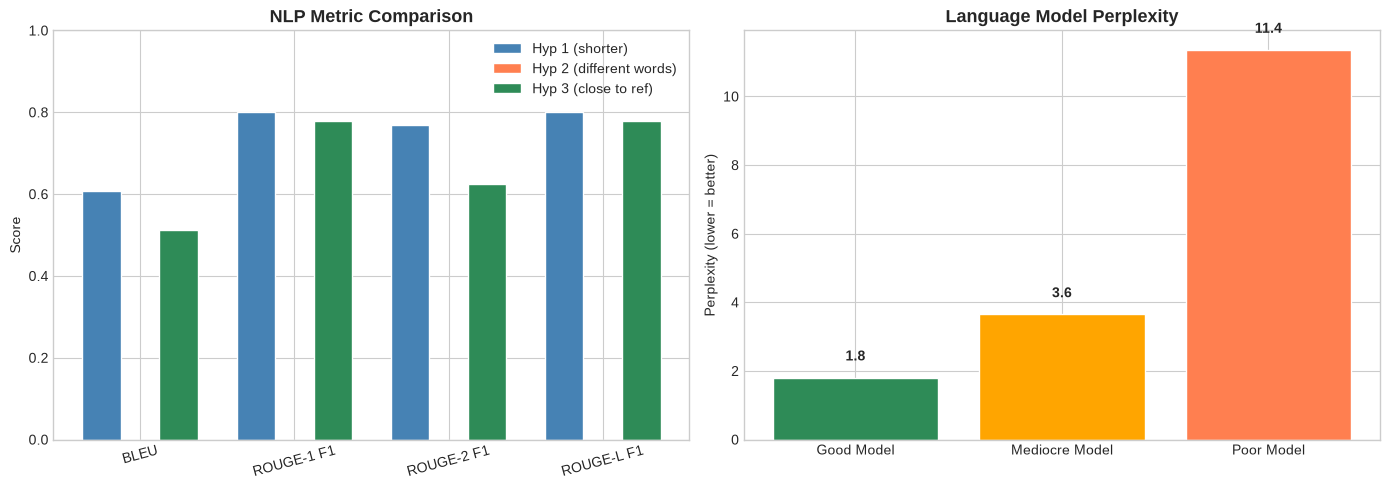

In [13]:
def compute_perplexity(ngram_model_probs):
    log_prob_sum = sum(math.log(max(p, 1e-10)) for p in ngram_model_probs)
    n = len(ngram_model_probs)
    return math.exp(-log_prob_sum / n)

np.random.seed(42)
n_tokens = 100
good_model_probs = np.random.uniform(0.3, 0.9, n_tokens)
med_model_probs = np.random.uniform(0.1, 0.5, n_tokens)
poor_model_probs = np.random.uniform(0.01, 0.2, n_tokens)

ppl_good = compute_perplexity(good_model_probs)
ppl_med = compute_perplexity(med_model_probs)
ppl_poor = compute_perplexity(poor_model_probs)

print("Perplexity Comparison:")
print(f"  Good model PPL:     {ppl_good:.2f} (lower = better)")
print(f"  Mediocre model PPL: {ppl_med:.2f}")
print(f"  Poor model PPL:     {ppl_poor:.2f}")

def chrf(reference, hypothesis, beta=1.0, char_order=6):
    def char_ngrams(text, n):
        text = text.replace(' ', '')
        return Counter([text[i:i+n] for i in range(len(text)-n+1)])
    total_prec = 0.0
    total_rec = 0.0
    for n in range(1, char_order + 1):
        ref_ng = char_ngrams(reference, n)
        hyp_ng = char_ngrams(hypothesis, n)
        overlap = sum(min(ref_ng[g], hyp_ng[g]) for g in ref_ng)
        total_prec += overlap / max(sum(hyp_ng.values()), 1)
        total_rec += overlap / max(sum(ref_ng.values()), 1)
    if total_prec == 0 or total_rec == 0:
        return 0.0
    prec = total_prec / char_order
    rec = total_rec / char_order
    return (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-10)

print("\nChrF Scores:")
for i, hyp in enumerate(hypotheses, 1):
    print(f"  Hypothesis {i}: {chrf(reference, hyp):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_names_nlp = ['BLEU', 'ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1']
scores_h1 = [bleu_score(reference, hypothesis1), rouge_n(reference, hypothesis1, 1)['f1'],
             rouge_n(reference, hypothesis1, 2)['f1'], rouge_l(reference, hypothesis1)['f1']]
scores_h2 = [bleu_score(reference, hypothesis2), rouge_n(reference, hypothesis2, 1)['f1'],
             rouge_n(reference, hypothesis2, 2)['f1'], rouge_l(reference, hypothesis2)['f1']]
scores_h3 = [bleu_score(reference, hypothesis3), rouge_n(reference, hypothesis3, 1)['f1'],
             rouge_n(reference, hypothesis3, 2)['f1'], rouge_l(reference, hypothesis3)['f1']]

x_nlp = np.arange(len(metrics_names_nlp))
width = 0.25
axes[0].bar(x_nlp - width, scores_h1, width, label='Hyp 1 (shorter)', color='steelblue', edgecolor='white')
axes[0].bar(x_nlp, scores_h2, width, label='Hyp 2 (different words)', color='coral', edgecolor='white')
axes[0].bar(x_nlp + width, scores_h3, width, label='Hyp 3 (close to ref)', color='seagreen', edgecolor='white')
axes[0].set_xticks(x_nlp)
axes[0].set_xticklabels(metrics_names_nlp, rotation=15)
axes[0].set_ylabel('Score')
axes[0].set_title('NLP Metric Comparison', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1)

model_names_ppl = ['Good Model', 'Mediocre Model', 'Poor Model']
ppls = [ppl_good, ppl_med, ppl_poor]
colors_ppl = ['seagreen', 'orange', 'coral']
axes[1].bar(model_names_ppl, ppls, color=colors_ppl, edgecolor='white')
axes[1].set_ylabel('Perplexity (lower = better)')
axes[1].set_title('Language Model Perplexity', fontsize=13, fontweight='bold')
for i, (nm, ppl) in enumerate(zip(model_names_ppl, ppls)):
    axes[1].text(i, ppl + 0.5, f'{ppl:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Computer Vision Metrics

### 6.1 Intersection over Union (IoU)
$$\text{IoU} = \frac{|A \cap B|}{|A \cup B|}$$
IoU = 0: no overlap; IoU = 1: perfect overlap. Common threshold: 0.5 for "correct" detection.

### 6.2 Mean Average Precision (mAP)
Used in object detection (COCO, PASCAL VOC):
- **mAP@0.5**: AP at IoU threshold 0.5
- **mAP@[0.5:0.95]**: mean AP over IoU thresholds 0.5, 0.55, ..., 0.95

### 6.3 Dice Score (F1 for segmentation)
$$\text{Dice} = \frac{2|A \cap B|}{|A| + |B|} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

### 6.4 FID (Frechet Inception Distance)
$$\text{FID} = \|\mu_r - \mu_g\|^2 + \text{Tr}\left(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}\right)$$
Lower FID = more realistic generated images. FID < 10 is considered excellent.

### 6.5 PSNR and SSIM
$$\text{PSNR} = 10 \cdot \log_{10}\left(\frac{\text{MAX}^2}{\text{MSE}}\right)$$
PSNR > 40 dB is generally considered high quality. SSIM measures perceptual similarity
across luminance, contrast, and structure. Range $[-1, 1]$, higher is better.

In [14]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    return intersection / union if union > 0 else 0.0

def dice_score(mask_true, mask_pred):
    intersection = np.sum(mask_true * mask_pred)
    return 2 * intersection / (np.sum(mask_true) + np.sum(mask_pred) + 1e-10)

def psnr(img_true, img_pred, max_val=255.0):
    mse_val = np.mean((img_true.astype(float) - img_pred.astype(float)) ** 2)
    if mse_val == 0:
        return float('inf')
    return 10 * np.log10(max_val**2 / mse_val)

def ssim_simple(img_true, img_pred, max_val=255.0):
    C1 = (0.01 * max_val) ** 2
    C2 = (0.03 * max_val) ** 2
    mu_x = np.mean(img_true)
    mu_y = np.mean(img_pred)
    sigma_x = np.var(img_true)
    sigma_y = np.var(img_pred)
    sigma_xy = np.mean((img_true - mu_x) * (img_pred - mu_y))
    numerator = (2 * mu_x * mu_y + C1) * (2 * sigma_xy + C2)
    denominator = (mu_x**2 + mu_y**2 + C1) * (sigma_x + sigma_y + C2)
    return numerator / denominator

boxes = [
    ([10, 10, 50, 50], [30, 30, 70, 70]),
    ([10, 10, 50, 50], [10, 10, 50, 50]),
    ([10, 10, 50, 50], [60, 60, 100, 100])
]
print("IoU Examples:")
for b1, b2 in boxes:
    print(f"  Box1={b1}, Box2={b2} -> IoU={compute_iou(b1, b2):.4f}")

np.random.seed(42)
true_mask = np.zeros((100, 100))
true_mask[30:70, 30:70] = 1
pred_mask_perfect = true_mask.copy()
pred_mask_slight = np.zeros((100, 100))
pred_mask_slight[35:75, 35:75] = 1
pred_mask_poor = np.zeros((100, 100))
pred_mask_poor[60:100, 60:100] = 1

print("\nSegmentation Metrics:")
for name, pred in [("Perfect", pred_mask_perfect), ("Slight offset", pred_mask_slight), ("Poor", pred_mask_poor)]:
    dice = dice_score(true_mask, pred)
    iou_seg = np.sum(true_mask * pred) / (np.sum((true_mask + pred) > 0) + 1e-10)
    print(f"  {name:<15}: Dice={dice:.4f}, IoU={iou_seg:.4f}")

img_original = np.random.randint(0, 256, (256, 256), dtype=np.uint8).astype(float)
noise_low = np.clip(img_original + np.random.normal(0, 5, img_original.shape), 0, 255)
noise_med = np.clip(img_original + np.random.normal(0, 25, img_original.shape), 0, 255)
noise_high = np.clip(img_original + np.random.normal(0, 50, img_original.shape), 0, 255)

print("\nImage Quality Metrics:")
print(f"{'Noise Level':<20} {'PSNR (dB)':<15} {'SSIM':<10}")
print("-" * 45)
for name, img in [("Low noise", noise_low), ("Medium noise", noise_med), ("High noise", noise_high)]:
    p = psnr(img_original, img)
    s = ssim_simple(img_original, img)
    print(f"{name:<20} {p:<15.2f} {s:<10.4f}")

IoU Examples:
  Box1=[10, 10, 50, 50], Box2=[30, 30, 70, 70] -> IoU=0.1429
  Box1=[10, 10, 50, 50], Box2=[10, 10, 50, 50] -> IoU=1.0000
  Box1=[10, 10, 50, 50], Box2=[60, 60, 100, 100] -> IoU=0.0000

Segmentation Metrics:
  Perfect        : Dice=1.0000, IoU=1.0000
  Slight offset  : Dice=0.7656, IoU=0.6203
  Poor           : Dice=0.0625, IoU=0.0323

Image Quality Metrics:
Noise Level          PSNR (dB)       SSIM      
---------------------------------------------
Low noise            34.25           0.9978    
Medium noise         20.63           0.9498    
High noise           15.17           0.8338    


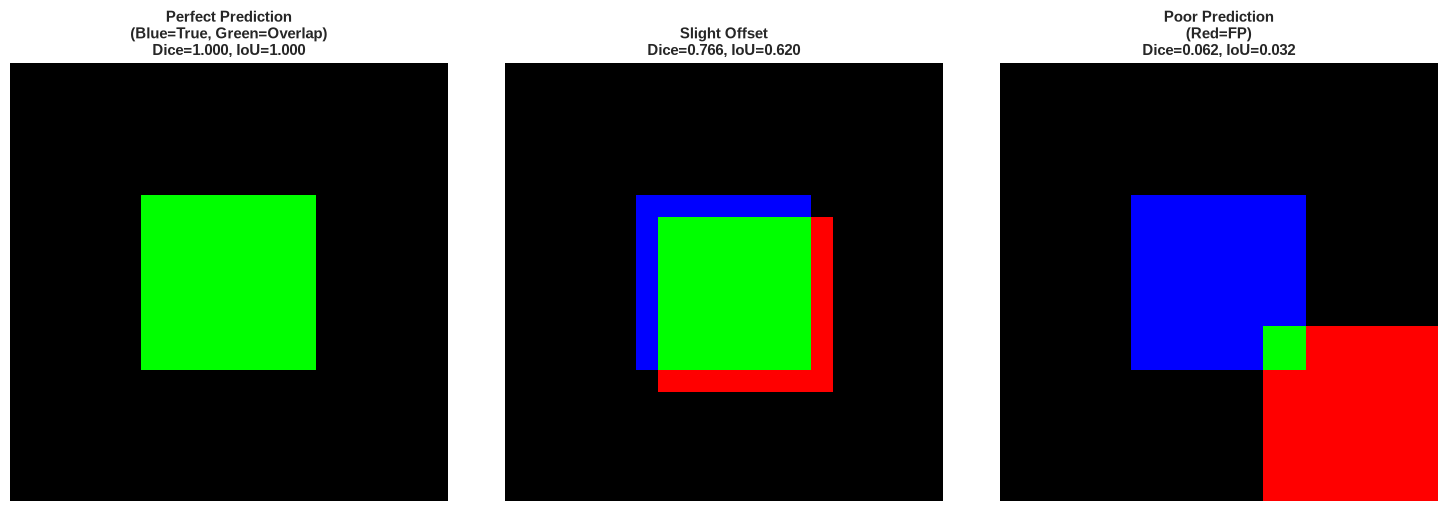

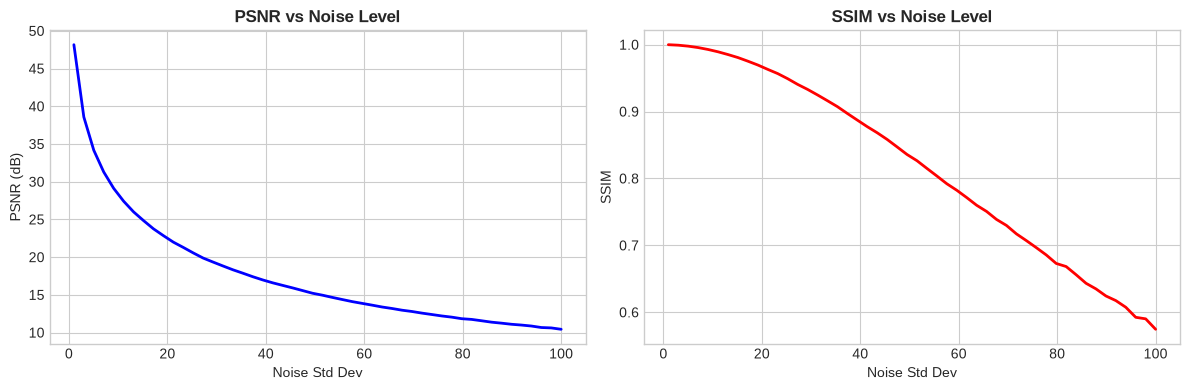

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def show_masks(ax, true_mask, pred_mask, title):
    overlay = np.zeros((*true_mask.shape, 3))
    overlay[true_mask == 1] = [0, 0, 1]
    overlap = (true_mask == 1) & (pred_mask == 1)
    overlay[overlap] = [0, 1, 0]
    only_pred = (true_mask == 0) & (pred_mask == 1)
    overlay[only_pred] = [1, 0, 0]
    ax.imshow(overlay)
    d = dice_score(true_mask, pred_mask)
    iou_v = np.sum(true_mask * pred_mask) / (np.sum((true_mask + pred_mask) > 0) + 1e-10)
    ax.set_title(f'{title}\nDice={d:.3f}, IoU={iou_v:.3f}', fontsize=11, fontweight='bold')
    ax.axis('off')

show_masks(axes[0], true_mask, pred_mask_perfect, 'Perfect Prediction\n(Blue=True, Green=Overlap)')
show_masks(axes[1], true_mask, pred_mask_slight, 'Slight Offset')
show_masks(axes[2], true_mask, pred_mask_poor, 'Poor Prediction\n(Red=FP)')
plt.tight_layout()
plt.show()

noise_stds = np.linspace(1, 100, 50)
psnrs = []
ssims = []
for std in noise_stds:
    noisy = np.clip(img_original + np.random.normal(0, std, img_original.shape), 0, 255)
    psnrs.append(psnr(img_original, noisy))
    ssims.append(ssim_simple(img_original, noisy))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(noise_stds, psnrs, 'b-', lw=2)
axes[0].set_xlabel('Noise Std Dev')
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('PSNR vs Noise Level', fontsize=12, fontweight='bold')
axes[1].plot(noise_stds, ssims, 'r-', lw=2)
axes[1].set_xlabel('Noise Std Dev')
axes[1].set_ylabel('SSIM')
axes[1].set_title('SSIM vs Noise Level', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Time Series Metrics

Standard metrics (MAE, RMSE, MAPE, sMAPE) apply to time series, but specialized metrics
account for autocorrelation and scale.

**MASE (Mean Absolute Scaled Error)** scale-free, comparable across series:
$$\text{MASE} = \frac{\text{MAE}}{\frac{1}{T-1}\sum_{t=2}^{T}|y_t - y_{t-1}|}$$
MASE = 1: same error as the naive (random walk) forecast. MASE < 1: beats naive.

**RMSSE (Root Mean Squared Scaled Error)**:
$$\text{RMSSE} = \sqrt{\frac{\frac{1}{h}\sum_{t=T+1}^{T+h}(y_t - \hat{y}_t)^2}{\frac{1}{T-1}\sum_{t=2}^{T}(y_t - y_{t-1})^2}}$$

**CRPS (Continuous Ranked Probability Score)** for probabilistic forecasts:
$$\text{CRPS}(F, y) = \int_{-\infty}^{\infty}(F(x) - \mathbf{1}(x \geq y))^2 dx$$
For Gaussian forecasts $N(\mu, \sigma^2)$:
$$\text{CRPS} = \sigma\left[z(2\Phi(z) - 1) + 2\phi(z) - \frac{1}{\sqrt{\pi}}\right], \quad z = \frac{y - \mu}{\sigma}$$

**Weighted Quantile Loss (WQL)**:
$$\text{WQL} = \frac{2\sum_{\tau}\sum_t L_\tau(y_t, q_\tau^t)}{\sum_t |y_t|}$$

In [16]:
np.random.seed(42)
T = 200
t_ts = np.arange(T)
trend_ts = 0.05 * t_ts
seasonality_ts = 10 * np.sin(2 * np.pi * t_ts / 12)
noise_ts = np.random.normal(0, 2, T)
y_ts = 50 + trend_ts + seasonality_ts + noise_ts

train_ts = y_ts[:160]
test_ts = y_ts[160:]

naive_forecast = np.repeat(train_ts[-1], len(test_ts))
seasonal_naive = np.array([train_ts[-12 + (i % 12)] for i in range(len(test_ts))])
trend_forecast = train_ts[-1] + 0.05 * np.arange(1, len(test_ts)+1)
perfect_forecast = test_ts + np.random.normal(0, 0.5, len(test_ts))

def ts_mae(y_true, y_pred): return np.mean(np.abs(y_true - y_pred))
def ts_rmse(y_true, y_pred): return np.sqrt(np.mean((y_true - y_pred)**2))
def ts_mape(y_true, y_pred, eps=1e-10): return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100
def ts_smape(y_true, y_pred, eps=1e-10): return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100

def ts_mase(y_true, y_pred, y_train):
    return np.mean(np.abs(y_true - y_pred)) / (np.mean(np.abs(np.diff(y_train))) + 1e-10)

def ts_rmsse(y_true, y_pred, y_train):
    return np.sqrt(np.mean((y_true - y_pred)**2) / (np.mean(np.diff(y_train)**2) + 1e-10))

def crps_normal(y_true, mu, sigma):
    from scipy.stats import norm
    z = (y_true - mu) / (sigma + 1e-10)
    crps = sigma * (z * (2*norm.cdf(z) - 1) + 2*norm.pdf(z) - 1/np.sqrt(np.pi))
    return np.mean(crps)

forecasts = {
    'Naive': naive_forecast,
    'Seasonal Naive': seasonal_naive,
    'Trend': trend_forecast,
    'Near-Perfect': perfect_forecast
}

print(f"{'Metric':<20} {'Naive':<12} {'Seas.Naive':<12} {'Trend':<12} {'Near-Perf':<12}")
print("="*68)
for metric_name, func in [('MAE', ts_mae), ('RMSE', ts_rmse), ('MAPE (%)', ts_mape), ('sMAPE (%)', ts_smape)]:
    vals = [func(test_ts, fc) for fc in forecasts.values()]
    print(f"{metric_name:<20} " + " ".join(f"{v:<12.4f}" for v in vals))

print(f"\n{'MASE':<20}", end="")
for fc in forecasts.values():
    print(f"{ts_mase(test_ts, fc, train_ts):<12.4f}", end="")
print()
print(f"{'RMSSE':<20}", end="")
for fc in forecasts.values():
    print(f"{ts_rmsse(test_ts, fc, train_ts):<12.4f}", end="")
print()
print(f"\nCRPS (Trend forecast, sigma=5): {crps_normal(test_ts, trend_forecast, 5.0):.4f}")

Metric               Naive        Seas.Naive   Trend        Near-Perf   
MAE                  10.0440      2.0555       10.9635      0.4432      
RMSE                 12.0080      2.6049       12.8443      0.5725      
MAPE (%)             18.4823      3.5189       20.0711      0.7434      
sMAPE (%)            16.2102      3.5926       17.5100      0.7421      

MASE                2.6797      0.5484      2.9250      0.1182      
RMSSE               2.6496      0.5748      2.8341      0.1263      

CRPS (Trend forecast, sigma=5): 8.7051


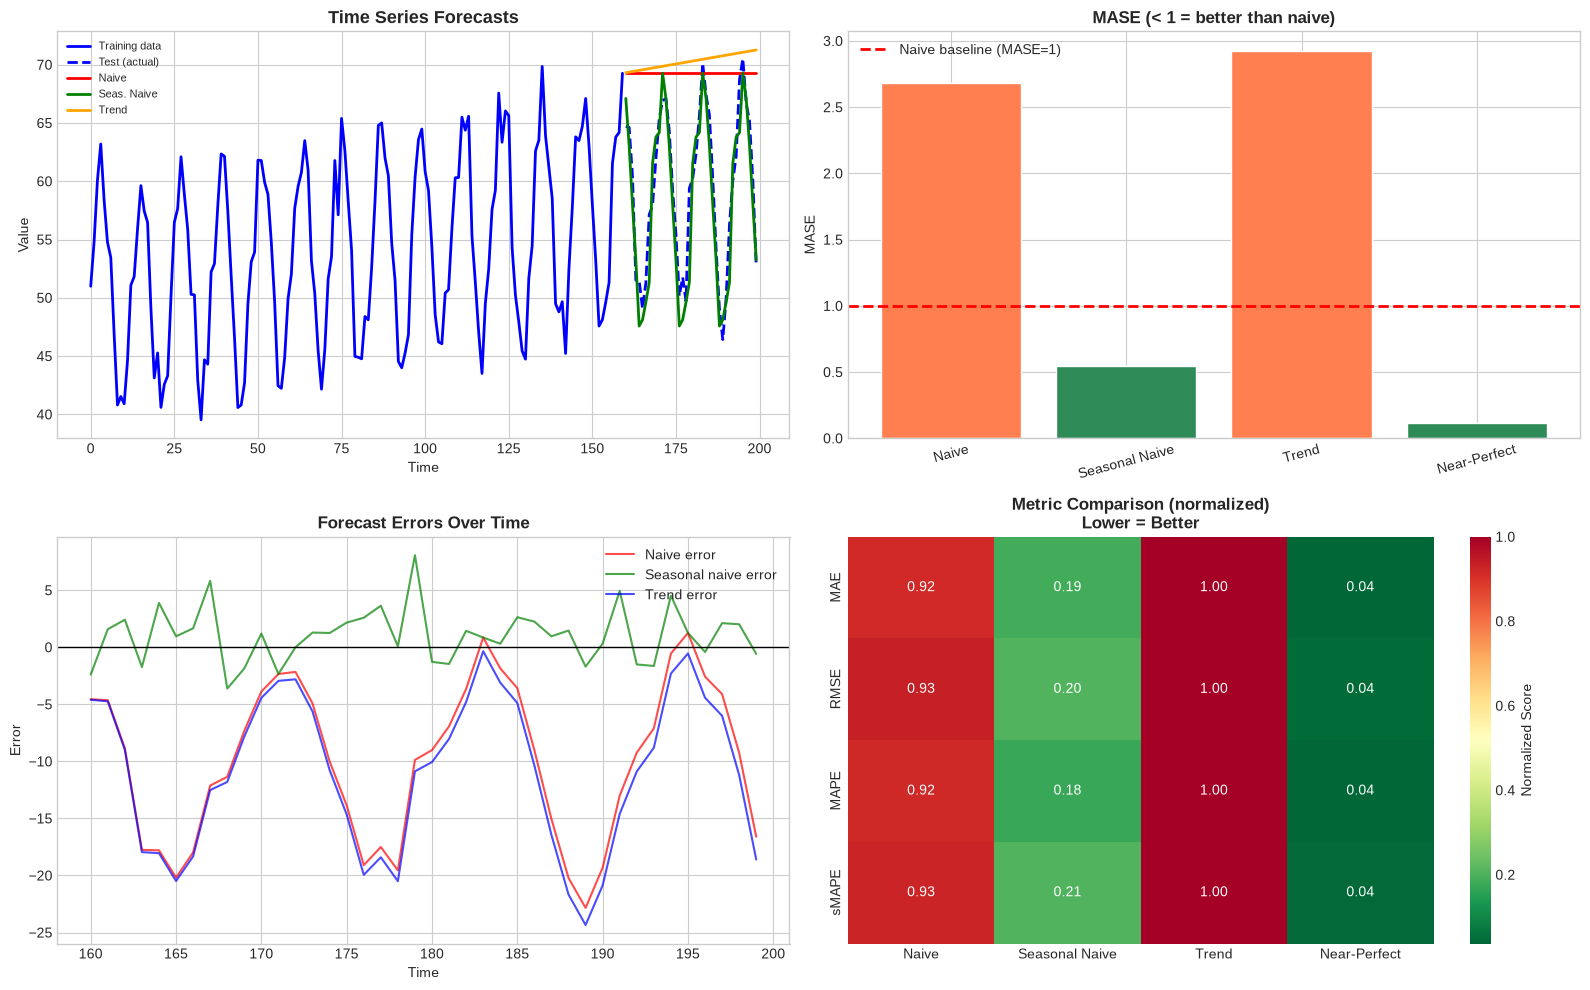

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(t_ts[:160], train_ts, 'b-', lw=2, label='Training data')
axes[0,0].plot(t_ts[160:], test_ts, 'b--', lw=2, label='Test (actual)')
for name, fc, color in zip(['Naive', 'Seas. Naive', 'Trend'],
                             [naive_forecast, seasonal_naive, trend_forecast],
                             ['red', 'green', 'orange']):
    axes[0,0].plot(t_ts[160:], fc, color=color, lw=2, label=name)
axes[0,0].set_title('Time Series Forecasts', fontsize=13, fontweight='bold')
axes[0,0].legend(fontsize=8)
axes[0,0].set_xlabel('Time')
axes[0,0].set_ylabel('Value')

mase_vals = [ts_mase(test_ts, fc, train_ts) for fc in forecasts.values()]
colors_ts_bar = ['coral' if v > 1 else 'seagreen' for v in mase_vals]
bars_ts = axes[0,1].bar(list(forecasts.keys()), mase_vals, color=colors_ts_bar, edgecolor='white')
axes[0,1].axhline(y=1.0, color='red', linestyle='--', lw=2, label='Naive baseline (MASE=1)')
axes[0,1].set_title('MASE (< 1 = better than naive)', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('MASE')
axes[0,1].legend()
axes[0,1].tick_params(axis='x', rotation=15)

axes[1,0].plot(t_ts[160:], test_ts - naive_forecast, 'r-', alpha=0.7, label='Naive error')
axes[1,0].plot(t_ts[160:], test_ts - seasonal_naive, 'g-', alpha=0.7, label='Seasonal naive error')
axes[1,0].plot(t_ts[160:], test_ts - trend_forecast, 'b-', alpha=0.7, label='Trend error')
axes[1,0].axhline(y=0, color='k', linestyle='-', lw=1)
axes[1,0].set_title('Forecast Errors Over Time', fontsize=12, fontweight='bold')
axes[1,0].legend()
axes[1,0].set_xlabel('Time')
axes[1,0].set_ylabel('Error')

metric_fns = [ts_mae, ts_rmse, ts_mape, ts_smape]
metric_names_ts = ['MAE', 'RMSE', 'MAPE', 'sMAPE']
heatmap_data = []
for fn in metric_fns:
    row = [fn(test_ts, fc) for fc in forecasts.values()]
    row_norm = np.array(row) / (max(row) + 1e-10)
    heatmap_data.append(row_norm)

heatmap_df = pd.DataFrame(heatmap_data, index=metric_names_ts, columns=list(forecasts.keys()))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=axes[1,1], cbar_kws={'label': 'Normalized Score'})
axes[1,1].set_title('Metric Comparison (normalized)\nLower = Better', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. RAG/LLM Evaluation Metrics

### RAGAS (Retrieval-Augmented Generation Assessment)

Four core metrics:
- **Faithfulness**: fraction of claims in the answer supported by retrieved context (measures hallucination)
- **Answer Relevancy**: semantic similarity of the answer to the original question
- **Context Precision**: fraction of retrieved contexts relevant to the question
- **Context Recall**: fraction of ground-truth information appearing in retrieved context

$$\text{RAGAS Score} = \text{HarmonicMean}(\text{Faithfulness}, \text{Answer Relevancy}, \text{Context Precision}, \text{Context Recall})$$

### G-Eval (LLM-as-Judge)

Uses chain-of-thought prompting with an LLM to score outputs on dimensions like coherence,
consistency, fluency, and relevance. Uses token probabilities for calibrated scoring:
$$\text{G-Eval Score} = \sum_{s=1}^{5} s \cdot P(\text{score}=s | \text{prompt, output})$$

### QAGs
Generates factual questions from a reference, then checks if the model answers correctly
measuring factual consistency without needing a reference answer.

### TruLens
Framework for evaluating LLM applications using feedback functions grading relevance,
groundedness, and other quality dimensions.

### DeepEval
Unit-test-like framework with metrics: hallucination score, answer relevancy, faithfulness,
contextual relevancy, RAGAS, G-Eval, summarization, and more.

RAGAS Evaluation Results:
Query  Faithfulness  Answer Relevancy  Context Precision  Context Recall  RAGAS Score
   Q1        0.6667            0.7596             0.3250          1.0000       0.6878
   Q2        0.6000            0.6728             0.4778          1.0000       0.6876
   Q3        0.8333            0.8121             0.2500          1.0000       0.7239
   Q4        0.7500            0.8434             0.2500          1.0000       0.7109
   Q5        0.8571            0.6943             0.8333          1.0000       0.8462

Mean RAGAS Score: 0.7313


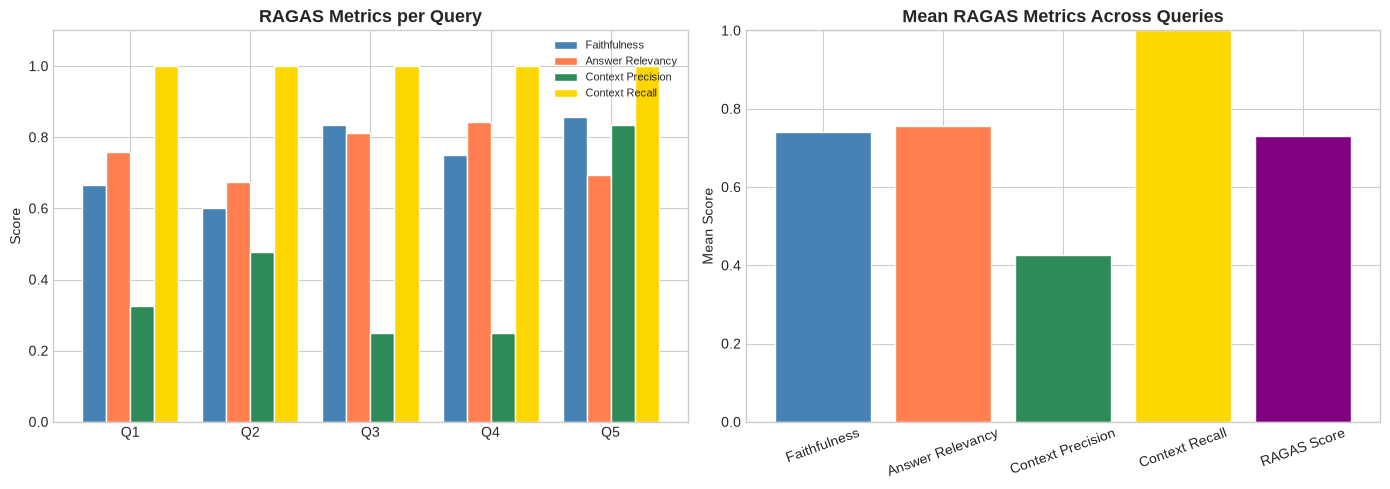


G-Eval Results (1-5 scale):
Query  Coherence  Consistency  Fluency  Relevance  G-Eval
   Q1       3.49         2.66     3.72       2.10    2.99
   Q2       3.34         3.13     5.00       3.04    3.63
   Q3       3.44         3.12     3.90       3.90    3.59
   Q4       4.12         4.24     4.96       4.04    4.34
   Q5       3.81         4.28     4.12       3.59    3.95


In [18]:
np.random.seed(42)

def simulate_faithfulness(answer_claims, context_facts):
    return len([c for c in answer_claims if c in context_facts]) / max(len(answer_claims), 1)

def simulate_context_precision(relevant_ranks, k):
    hits = 0
    precision_sum = 0.0
    for i, r in enumerate(relevant_ranks[:k]):
        if r == 1:
            hits += 1
            precision_sum += hits / (i + 1)
    return precision_sum / max(hits, 1)

def simulate_context_recall(retrieved_facts, ground_truth_facts):
    attributable = sum(1 for f in ground_truth_facts if f in retrieved_facts)
    return attributable / max(len(ground_truth_facts), 1)

n_eval = 5
results = []
for i in range(n_eval):
    n_claims = np.random.randint(3, 8)
    n_context_facts = np.random.randint(5, 12)
    context_facts = set(range(n_context_facts))
    answer_claims = set(np.random.choice(n_context_facts + 3, n_claims, replace=False))
    n_gt_facts = np.random.randint(4, 10)
    retrieved_facts = set(np.random.choice(n_gt_facts + 2, min(n_context_facts, n_gt_facts + 2), replace=False))
    ground_truth_facts = set(range(n_gt_facts))
    relevant_ranks = np.random.choice([0, 1], 10, p=[0.4, 0.6]).tolist()
    faithfulness = simulate_faithfulness(answer_claims, context_facts)
    answer_rel = np.random.uniform(0.6, 0.95)
    ctx_precision = simulate_context_precision(relevant_ranks, k=5)
    ctx_recall = simulate_context_recall(retrieved_facts, ground_truth_facts)
    ragas_score = np.mean([faithfulness, answer_rel, ctx_precision, ctx_recall])
    results.append({'Query': f'Q{i+1}', 'Faithfulness': faithfulness,
                    'Answer Relevancy': answer_rel, 'Context Precision': ctx_precision,
                    'Context Recall': ctx_recall, 'RAGAS Score': ragas_score})

df_ragas = pd.DataFrame(results)
print("RAGAS Evaluation Results:")
print(df_ragas.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f"\nMean RAGAS Score: {df_ragas['RAGAS Score'].mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_rag = np.arange(len(df_ragas))
width = 0.2
metrics_rag = ['Faithfulness', 'Answer Relevancy', 'Context Precision', 'Context Recall']
colors_rag = ['steelblue', 'coral', 'seagreen', 'gold']
for i, (metric, color) in enumerate(zip(metrics_rag, colors_rag)):
    axes[0].bar(x_rag + i*width, df_ragas[metric], width, label=metric, color=color, edgecolor='white')
axes[0].set_xticks(x_rag + width*1.5)
axes[0].set_xticklabels(df_ragas['Query'])
axes[0].set_ylabel('Score')
axes[0].set_title('RAGAS Metrics per Query', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.1)

axes[1].bar(metrics_rag + ['RAGAS Score'],
            list(df_ragas[metrics_rag].mean()) + [df_ragas['RAGAS Score'].mean()],
            color=colors_rag + ['purple'], edgecolor='white')
axes[1].set_ylabel('Mean Score')
axes[1].set_title('Mean RAGAS Metrics Across Queries', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

geval_scores = pd.DataFrame({
    'Query': [f'Q{i}' for i in range(1, 6)],
    'Coherence': np.random.uniform(3, 5, 5),
    'Consistency': np.random.uniform(2.5, 5, 5),
    'Fluency': np.random.uniform(3.5, 5, 5),
    'Relevance': np.random.uniform(2, 5, 5)
})
geval_scores['G-Eval'] = geval_scores[['Coherence','Consistency','Fluency','Relevance']].mean(axis=1)
print("\nG-Eval Results (1-5 scale):")
print(geval_scores.to_string(index=False, float_format=lambda x: f'{x:.2f}'))

## 9. Statistical Significance Testing

A single train/test split can be misleading. Statistical tests determine whether observed
differences between models are genuine or due to random chance.

### Paired t-test
Assumes normally distributed differences. Tests if mean difference $\bar{d} = 0$:
$$t = \frac{\bar{d}}{s_d/\sqrt{n}} \sim t_{n-1}$$

### Wilcoxon Signed-Rank Test
Non-parametric alternative to the paired t-test. Robust to outliers and non-normality.
Tests if the median difference is zero.

### Bootstrap Confidence Intervals
Resample differences with replacement $B$ times to estimate CI for mean difference:
$$\text{CI}_{1-\alpha} = [\hat{\theta}_{\alpha/2}^*, \hat{\theta}_{1-\alpha/2}^*]$$
If CI excludes 0, the difference is statistically significant.

### Friedman Test
Non-parametric test for comparing $k$ models across $n$ datasets/folds simultaneously:
$$\chi^2_F = \frac{12n}{k(k+1)}\sum_{j=1}^{k}\left(\bar{r}_j - \frac{k+1}{2}\right)^2$$
where $\bar{r}_j$ is the mean rank of model $j$. Reject $H_0$ if $\chi^2_F > \chi^2_{k-1, \alpha}$.

In [19]:
from scipy.stats import ttest_rel
import itertools

np.random.seed(42)
n_folds = 10
model_a_scores = 0.82 + np.random.normal(0, 0.02, n_folds)
model_b_scores = 0.79 + np.random.normal(0, 0.025, n_folds)
model_c_scores = 0.76 + np.random.normal(0, 0.03, n_folds)

scores = {'Model A': model_a_scores, 'Model B': model_b_scores, 'Model C': model_c_scores}

print("Model Performance (10-Fold CV Accuracy):")
for name, sc in scores.items():
    print(f"  {name}: {sc.mean():.4f} +/- {sc.std():.4f}")

alpha = 0.05
pairs = list(itertools.combinations(scores.keys(), 2))

print("\nPaired t-tests (two-sided):")
print(f"{'Comparison':<25} {'t-stat':<12} {'p-value':<12} {'Significant':<12}")
print("-" * 61)
for m1, m2 in pairs:
    t_stat, p_val = ttest_rel(scores[m1], scores[m2])
    sig = "Yes" if p_val < alpha else "No"
    print(f"{m1+' vs '+m2:<25} {t_stat:<12.4f} {p_val:<12.4f} {sig}")

print("\nWilcoxon Signed-Rank Tests:")
print(f"{'Comparison':<25} {'statistic':<12} {'p-value':<12} {'Significant':<12}")
print("-" * 61)
for m1, m2 in pairs:
    try:
        stat, p_val = wilcoxon(scores[m1], scores[m2])
        sig = "Yes" if p_val < alpha else "No"
        print(f"{m1+' vs '+m2:<25} {stat:<12.4f} {p_val:<12.4f} {sig}")
    except Exception as e:
        print(f"{m1+' vs '+m2:<25} Error: {e}")

stat_f, p_f = friedmanchisquare(*scores.values())
print(f"\nFriedman Test (all 3 models):")
print(f"  Chi^2 statistic: {stat_f:.4f}")
print(f"  p-value:         {p_f:.4f}")
print(f"  Significant:     {'Yes' if p_f < alpha else 'No'}")

def bootstrap_ci(scores1, scores2, n_bootstrap=10000, alpha=0.05):
    diffs = scores1 - scores2
    boot_diffs = np.array([np.mean(np.random.choice(diffs, len(diffs))) for _ in range(n_bootstrap)])
    ci_lower = np.percentile(boot_diffs, 100 * alpha/2)
    ci_upper = np.percentile(boot_diffs, 100 * (1 - alpha/2))
    return ci_lower, ci_upper, np.mean(diffs)

print("\nBootstrap 95% CI for mean differences:")
for m1, m2 in pairs:
    ci_low, ci_high, mean_diff = bootstrap_ci(scores[m1], scores[m2])
    sig = "Yes" if ci_low > 0 or ci_high < 0 else "No"
    print(f"  {m1} vs {m2}: diff={mean_diff:.4f}, CI=[{ci_low:.4f}, {ci_high:.4f}], Sig={sig}")

Model Performance (10-Fold CV Accuracy):
  Model A: 0.8290 +/- 0.0137
  Model B: 0.7702 +/- 0.0179
  Model C: 0.7533 +/- 0.0232

Paired t-tests (two-sided):
Comparison                t-stat       p-value      Significant 
-------------------------------------------------------------
Model A vs Model B        7.4225       0.0000       Yes
Model A vs Model C        7.4547       0.0000       Yes
Model B vs Model C        2.7990       0.0207       Yes

Wilcoxon Signed-Rank Tests:
Comparison                statistic    p-value      Significant 
-------------------------------------------------------------
Model A vs Model B        0.0000       0.0020       Yes
Model A vs Model C        0.0000       0.0020       Yes
Model B vs Model C        7.0000       0.0371       Yes

Friedman Test (all 3 models):
  Chi^2 statistic: 18.2000
  p-value:         0.0001
  Significant:     Yes

Bootstrap 95% CI for mean differences:


  Model A vs Model B: diff=0.0587, CI=[0.0451, 0.0739], Sig=Yes


  Model A vs Model C: diff=0.0756, CI=[0.0575, 0.0951], Sig=Yes


  Model B vs Model C: diff=0.0169, CI=[0.0051, 0.0272], Sig=Yes


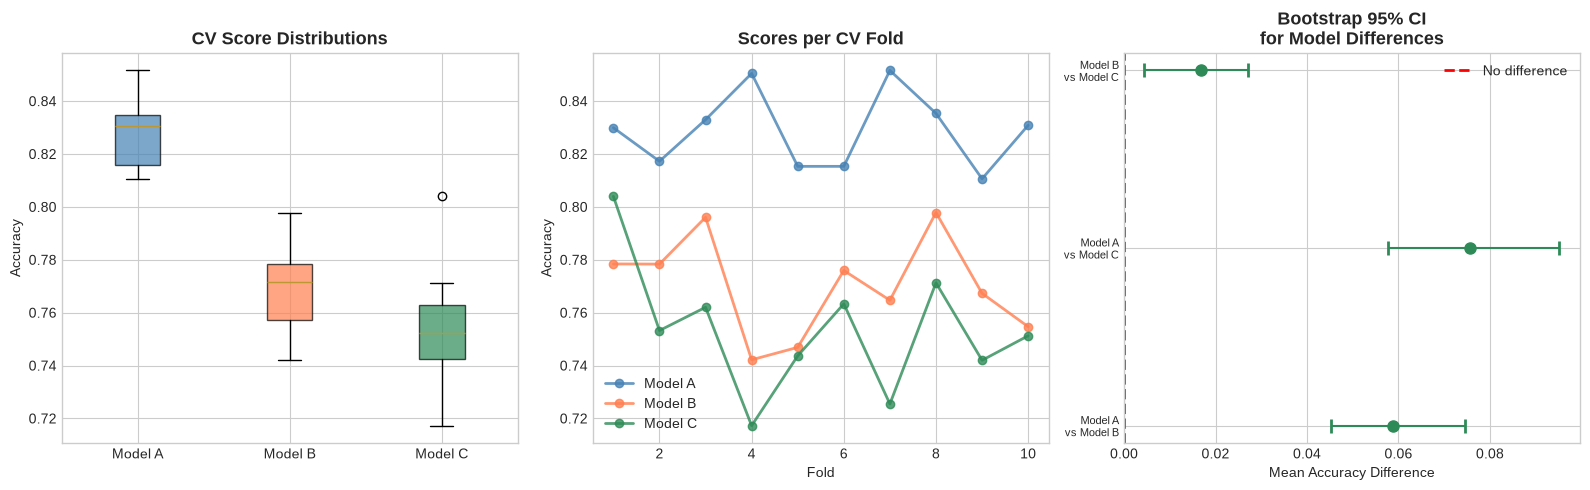

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bp_data = [model_a_scores, model_b_scores, model_c_scores]
bp = axes[0].boxplot(bp_data, tick_labels=['Model A', 'Model B', 'Model C'],
                     patch_artist=True, notch=False)
colors_box = ['steelblue', 'coral', 'seagreen']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('CV Score Distributions', fontsize=13, fontweight='bold')

fold_nums = list(range(1, n_folds+1))
for name, sc, color in zip(scores.keys(), bp_data, colors_box):
    axes[1].plot(fold_nums, sc, 'o-', color=color, lw=2, label=name, alpha=0.8)
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Scores per CV Fold', fontsize=13, fontweight='bold')
axes[1].legend()

ci_results = []
for m1, m2 in pairs:
    ci_low, ci_high, mean_diff = bootstrap_ci(scores[m1], scores[m2])
    ci_results.append({'comparison': f'{m1}\nvs {m2}', 'mean': mean_diff,
                       'lower': ci_low, 'upper': ci_high})

ci_df = pd.DataFrame(ci_results)
for i, row in ci_df.iterrows():
    color = 'seagreen' if row['lower'] > 0 else ('coral' if row['upper'] < 0 else 'gray')
    axes[2].errorbar(row['mean'], i,
                     xerr=[[row['mean'] - row['lower']], [row['upper'] - row['mean']]],
                     fmt='o', color=color, capsize=5, capthick=2, markersize=8)

axes[2].axvline(x=0, color='red', linestyle='--', lw=2, label='No difference')
axes[2].set_yticks(range(len(ci_df)))
axes[2].set_yticklabels([r['comparison'] for r in ci_results], fontsize=8)
axes[2].set_xlabel('Mean Accuracy Difference')
axes[2].set_title('Bootstrap 95% CI\nfor Model Differences', fontsize=13, fontweight='bold')
axes[2].legend()
plt.tight_layout()
plt.show()

## 10. Metric Selection Guide

| Task | Primary Metric | Secondary | Notes |
|------|---------------|-----------|-------|
| Binary Classification (balanced) | F1-Score | AUC-ROC | Both at 0.5 threshold |
| Binary Classification (imbalanced) | MCC or AUC-PR | Weighted F1 | Avoid accuracy alone |
| Multi-class (balanced) | Macro F1 | Accuracy | Equal class weight |
| Multi-class (imbalanced) | Weighted F1 | MCC | Accounts for support |
| Regression (normal) | R², RMSE | MAE | RMSE penalizes outliers |
| Regression (robust) | MAE, Huber | RMSE | Huber: tunable delta |
| Regression (relative error) | sMAPE | MAPE | MAPE fails when y≈0 |
| Ranking | NDCG@k | MAP, MRR | k depends on use case |
| Clustering (no labels) | Silhouette | Davies-Bouldin | Both for confirmation |
| NLP Generation | ROUGE-L | BLEU | BLEU alone insufficient |
| Image Quality | SSIM | PSNR | SSIM is perceptual |
| Image Generation | FID | IS | FID needs many samples |
| Time Series | MASE | sMAPE | MASE = scale-free |
| RAG/LLM | RAGAS | G-Eval | Need LLM calls for RAGAS |

**General principles:**
1. Use multiple metrics no single metric captures everything
2. Always run statistical significance tests before claiming one model is better
3. Consider the business cost of FP vs FN for classification tasks
4. For imbalanced data: MCC > F1 > Accuracy
5. For time series, always benchmark against naive forecasts (MASE)
6. For NLP, human evaluation remains the gold standard

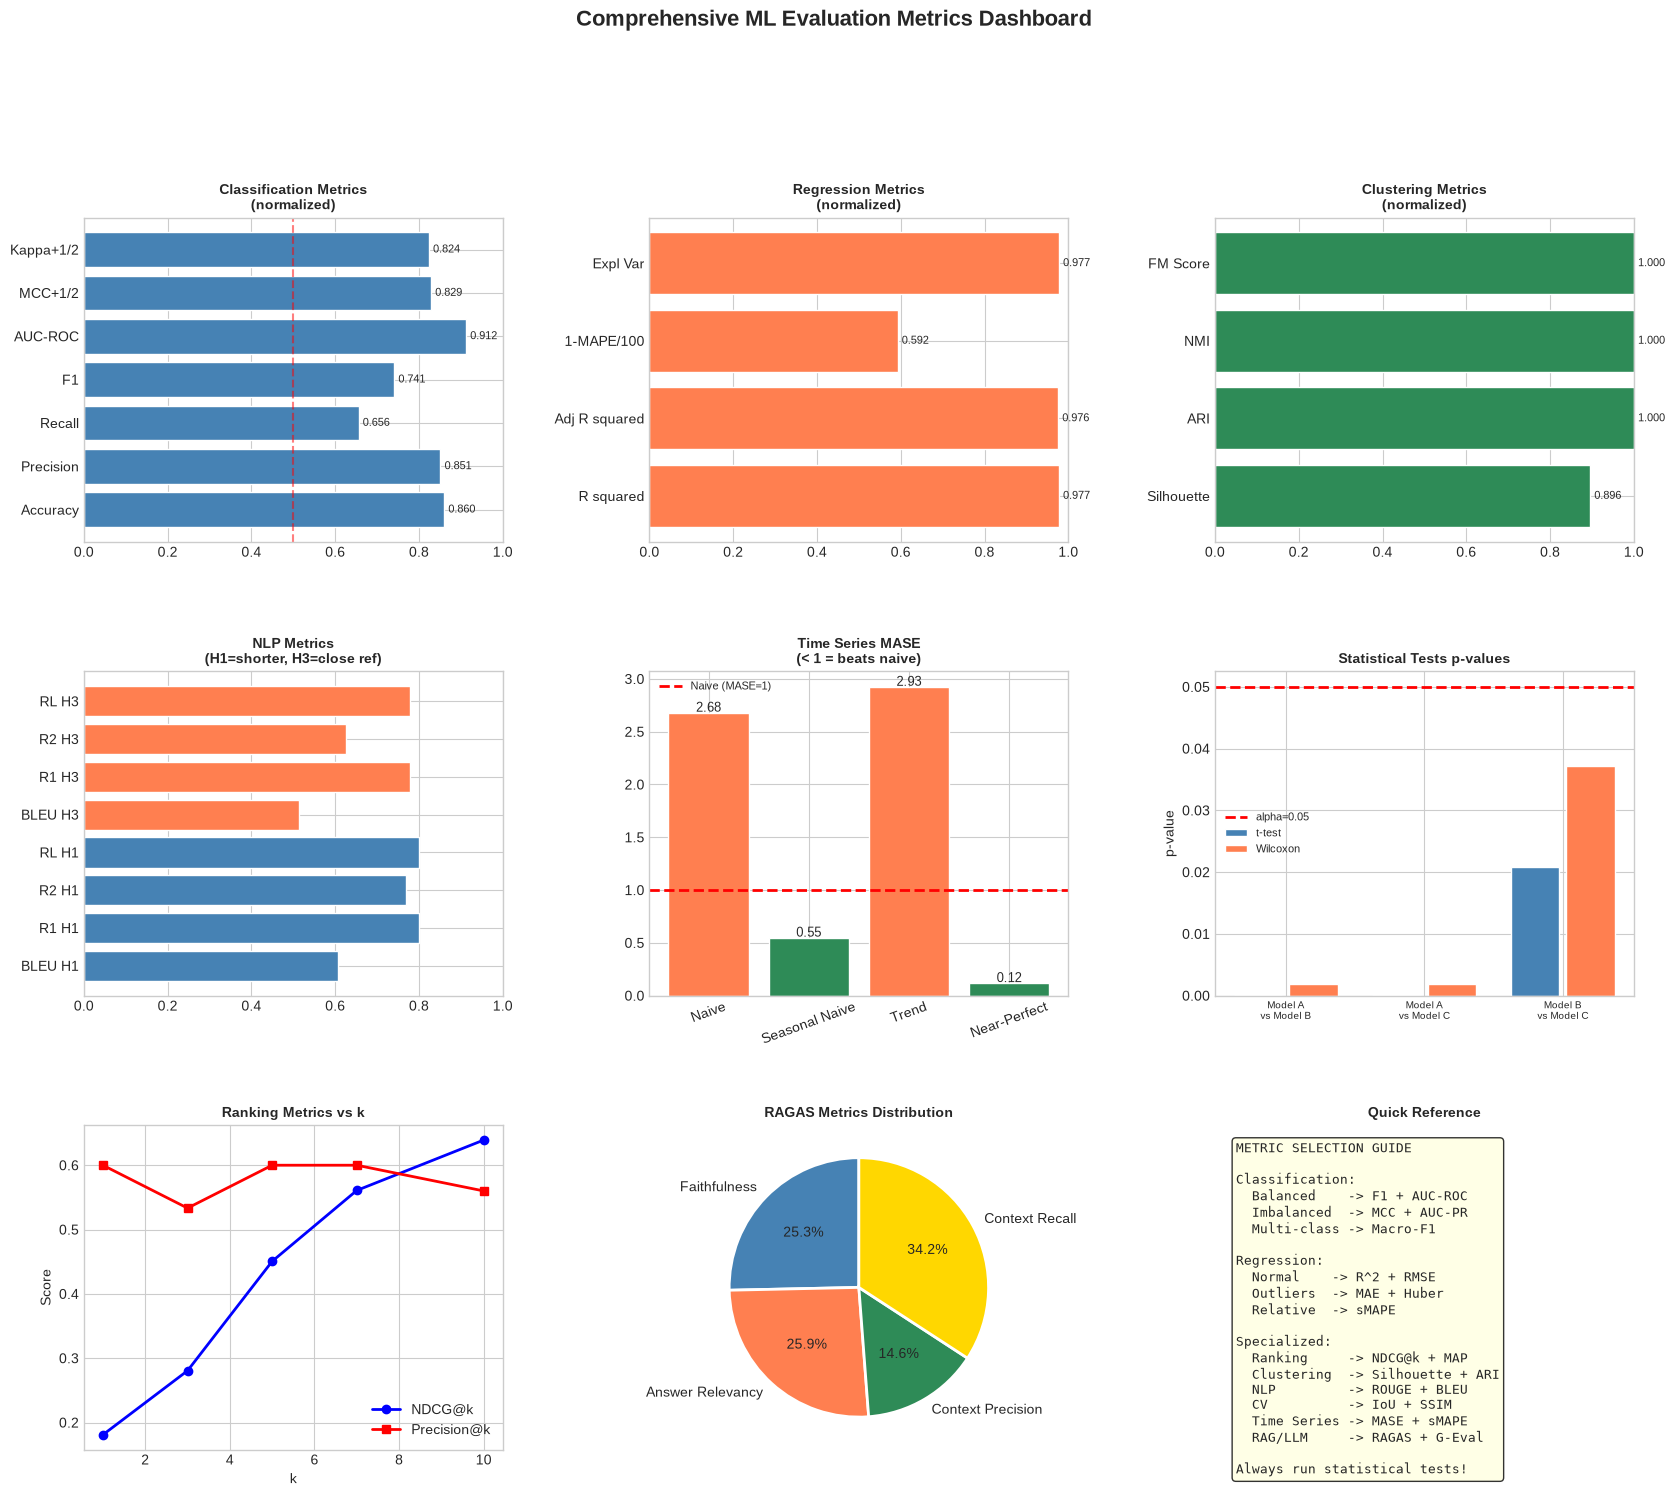

Dashboard complete!


In [21]:
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
clf_metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC', 'MCC+1/2', 'Kappa+1/2']
clf_vals = [
    accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
    recall_score(y_test, y_pred), f1_score(y_test, y_pred),
    roc_auc_score(y_test, y_prob),
    (mcc_scratch(y_test, y_pred) + 1) / 2,
    (cohen_kappa_score(y_test, y_pred) + 1) / 2
]
ax1.barh(clf_metrics_names, clf_vals, color='steelblue', edgecolor='white')
ax1.set_xlim(0, 1)
ax1.set_title('Classification Metrics\n(normalized)', fontsize=10, fontweight='bold')
ax1.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
for i, v in enumerate(clf_vals):
    ax1.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)

ax2 = fig.add_subplot(gs[0, 1])
reg_labels = ['R squared', 'Adj R squared', '1-MAPE/100', 'Expl Var']
adj_r2_val = adjusted_r2_scratch(y_te_r, y_pred_r, p)
mape_norm = 1 - min(mape_scratch(y_te_r, y_pred_r) / 100, 1)
reg_vals_norm = [r2, max(adj_r2_val, 0), mape_norm, explained_variance_score(y_te_r, y_pred_r)]
ax2.barh(reg_labels, reg_vals_norm, color='coral', edgecolor='white')
ax2.set_xlim(0, 1)
ax2.set_title('Regression Metrics\n(normalized)', fontsize=10, fontweight='bold')
for i, v in enumerate(reg_vals_norm):
    ax2.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)

ax3 = fig.add_subplot(gs[0, 2])
clust_labels = ['Silhouette', 'ARI', 'NMI', 'FM Score']
clust_vals_norm = [
    (metrics_k4['Silhouette'] + 1) / 2,
    (metrics_k4['ARI'] + 1) / 2,
    metrics_k4['NMI'],
    metrics_k4['Fowlkes-Mallows']
]
ax3.barh(clust_labels, clust_vals_norm, color='seagreen', edgecolor='white')
ax3.set_xlim(0, 1)
ax3.set_title('Clustering Metrics\n(normalized)', fontsize=10, fontweight='bold')
for i, v in enumerate(clust_vals_norm):
    ax3.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)

ax4 = fig.add_subplot(gs[1, 0])
nlp_labels_dash = ['BLEU H1', 'R1 H1', 'R2 H1', 'RL H1', 'BLEU H3', 'R1 H3', 'R2 H3', 'RL H3']
nlp_vals_dash = [
    bleu_score(reference, hypothesis1), rouge_n(reference, hypothesis1, 1)['f1'],
    rouge_n(reference, hypothesis1, 2)['f1'], rouge_l(reference, hypothesis1)['f1'],
    bleu_score(reference, hypothesis3), rouge_n(reference, hypothesis3, 1)['f1'],
    rouge_n(reference, hypothesis3, 2)['f1'], rouge_l(reference, hypothesis3)['f1']
]
colors_nlp_dash = ['steelblue']*4 + ['coral']*4
ax4.barh(nlp_labels_dash, nlp_vals_dash, color=colors_nlp_dash, edgecolor='white')
ax4.set_xlim(0, 1)
ax4.set_title('NLP Metrics\n(H1=shorter, H3=close ref)', fontsize=10, fontweight='bold')

ax5 = fig.add_subplot(gs[1, 1])
ts_names = list(forecasts.keys())
mase_scores_all = [ts_mase(test_ts, fc, train_ts) for fc in forecasts.values()]
colors_ts_dash = ['coral' if v > 1 else 'seagreen' for v in mase_scores_all]
bars_ts_dash = ax5.bar(ts_names, mase_scores_all, color=colors_ts_dash, edgecolor='white')
ax5.axhline(y=1.0, color='red', linestyle='--', lw=2, label='Naive (MASE=1)')
ax5.set_title('Time Series MASE\n(< 1 = beats naive)', fontsize=10, fontweight='bold')
ax5.legend(fontsize=8)
ax5.tick_params(axis='x', rotation=20)
for bar, v in zip(bars_ts_dash, mase_scores_all):
    ax5.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

ax6 = fig.add_subplot(gs[1, 2])
comparisons_stat = [f"{m1}\nvs {m2}" for m1, m2 in pairs]
p_values_t = []
p_values_w = []
for m1, m2 in pairs:
    _, p_t = ttest_rel(scores[m1], scores[m2])
    p_values_t.append(p_t)
    try:
        _, p_w = wilcoxon(scores[m1], scores[m2])
    except Exception:
        p_w = 1.0
    p_values_w.append(p_w)

x_stat = np.arange(len(comparisons_stat))
ax6.bar(x_stat - 0.2, p_values_t, 0.35, label='t-test', color='steelblue', edgecolor='white')
ax6.bar(x_stat + 0.2, p_values_w, 0.35, label='Wilcoxon', color='coral', edgecolor='white')
ax6.axhline(y=0.05, color='red', linestyle='--', lw=2, label='alpha=0.05')
ax6.set_xticks(x_stat)
ax6.set_xticklabels(comparisons_stat, fontsize=7)
ax6.set_ylabel('p-value')
ax6.set_title('Statistical Tests p-values', fontsize=10, fontweight='bold')
ax6.legend(fontsize=8)

ax7 = fig.add_subplot(gs[2, 0])
k_vals = [1, 3, 5, 7, 10]
ndcg_at_ks = [np.mean([ndcg_at_k(r, kv) for r in queries_relevances]) for kv in k_vals]
pr_at_ks = [np.mean([precision_at_k(r, kv) for r in queries_relevances]) for kv in k_vals]
ax7.plot(k_vals, ndcg_at_ks, 'b-o', lw=2, label='NDCG@k')
ax7.plot(k_vals, pr_at_ks, 'r-s', lw=2, label='Precision@k')
ax7.set_xlabel('k')
ax7.set_ylabel('Score')
ax7.set_title('Ranking Metrics vs k', fontsize=10, fontweight='bold')
ax7.legend()

ax8 = fig.add_subplot(gs[2, 1])
ragas_means = df_ragas[['Faithfulness', 'Answer Relevancy', 'Context Precision', 'Context Recall']].mean()
wedge_props = {'linewidth': 2, 'edgecolor': 'white'}
ax8.pie(ragas_means, labels=ragas_means.index, autopct='%1.1f%%',
        colors=['steelblue', 'coral', 'seagreen', 'gold'],
        wedgeprops=wedge_props, startangle=90)
ax8.set_title('RAGAS Metrics Distribution', fontsize=10, fontweight='bold')

ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')
decision_text = (
    "METRIC SELECTION GUIDE\n\n"
    "Classification:\n"
    "  Balanced    -> F1 + AUC-ROC\n"
    "  Imbalanced  -> MCC + AUC-PR\n"
    "  Multi-class -> Macro-F1\n\n"
    "Regression:\n"
    "  Normal    -> R^2 + RMSE\n"
    "  Outliers  -> MAE + Huber\n"
    "  Relative  -> sMAPE\n\n"
    "Specialized:\n"
    "  Ranking     -> NDCG@k + MAP\n"
    "  Clustering  -> Silhouette + ARI\n"
    "  NLP         -> ROUGE + BLEU\n"
    "  CV          -> IoU + SSIM\n"
    "  Time Series -> MASE + sMAPE\n"
    "  RAG/LLM     -> RAGAS + G-Eval\n\n"
    "Always run statistical tests!"
)
ax9.text(0.05, 0.95, decision_text, transform=ax9.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax9.set_title('Quick Reference', fontsize=10, fontweight='bold')

fig.suptitle('Comprehensive ML Evaluation Metrics Dashboard',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("Dashboard complete!")

## Additional Learning Resources

### Foundational Papers
- Sokolova, M., & Lapalme, G. (2009). "A systematic analysis of performance measures for classification tasks." *Information Processing & Management*.
- Chicco, D., & Jurman, G. (2020). "The advantages of the MCC over F1 score and accuracy in binary classification evaluation." *BMC Genomics*.
- Powers, D.M.W. (2011). "Evaluation: From Precision, Recall and F-Measure to ROC, Informedness, Markedness and Correlation." *JMLR*.

### NLP Metrics
- Papineni, K. et al. (2002). "BLEU: a Method for Automatic Evaluation of Machine Translation." *ACL*.
- Lin, C.Y. (2004). "ROUGE: A Package for Automatic Evaluation of Summaries." *ACL Workshop*.
- Zhang, T. et al. (2020). "BERTScore: Evaluating Text Generation with BERT." *ICLR*.

### RAG/LLM Evaluation
- Es, S. et al. (2023). "RAGAS: Automated Evaluation of Retrieval Augmented Generation." *arXiv:2309.15217*.
- Liu, Y. et al. (2023). "G-Eval: NLG Evaluation using GPT-4 with Better Human Alignment." *arXiv:2303.16634*.

### Computer Vision
- Wang, Z. et al. (2004). "Image Quality Assessment: From Error Visibility to Structural Similarity." *IEEE TIP*. (SSIM)
- Heusel, M. et al. (2017). "GANs Trained by a Two Time-Scale Update Rule..." *NeurIPS*. (FID)

### Time Series
- Hyndman, R.J. & Koehler, A.B. (2006). "Another look at measures of forecast accuracy." *International Journal of Forecasting*.
- Makridakis, S. et al. (2020). "The M4 Competition: 100,000 time series and 61 forecasting methods." *International Journal of Forecasting*.

### Documentation and Tools
- scikit-learn metrics: https://scikit-learn.org/stable/modules/model_evaluation.html
- sacrebleu: https://github.com/mjpost/sacrebleu
- RAGAS docs: https://docs.ragas.io
- DeepEval: https://docs.confident-ai.com

### Courses
- Fast.ai: Practical Deep Learning for Coders
- Stanford CS229: Machine Learning
- Hugging Face NLP Course

---
*Notebook covers 9 metric categories, 60+ individual metrics, from-scratch implementations, visualizations, and statistical testing.*